<a href="https://colab.research.google.com/github/aaronkht06/ai-regulation-campaign/blob/main/Python_Pioneers_Data_Project_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMSC 206 Python Pioneers Group Project

Start-Up/Skeleton Code

In [ ]:
# Authors of this project: Brandon Hoang, Huda Riaz, Aung Kaung Khant, Natnael Rezene
# Author of this cell: Brandon Hoang, Natnael Rezene
# Professor: Gary Thai
# Class: CMSC 206

# DESIGN NOTES:
# This cell will be the startup code for this group project
# The purpose of this code is to help the overall program gain access to the
# pokemon, magic, and one piece API's, get the raw JSON data from each of
# those API's, convert that raw JSON data into Pandas Data Frames,
# Clean and standardize each of the columns we make, combine the three games
# into one master Data Frame, and show a basic summary before we actually get
# to answering our individual questions
# Also, I am not too sure what happens when we run all the cells together at
# once since we usually ran them individually one by one from top to bottom

# This imports all of the libraies we will need
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt

# This will make it so that Pandas prints out the tables in a better way for
# Google colab
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)

# These will be the helper functions our program will use

# This function tries to convert a value into a float
# If the program cannot convert the value, it should return None
def safe_float(value):
  try:
    if value is None or value == "":
      return None
    return float(value)
  except:
    return None

# This function helps us print a section title to make the output easier for
# users to read
def print_out_program_title(title_text):
  print("\n" + "=" * 30)
  print(title_text)
  print("=" * 30)

# This will create the API access functions that our program will use throughout

# This function gets us 1500 pokemon card data from the Pokemon
# TCG API
def get_pokemon_api_data(target_cards=1500):

  # This is the API endpoint for the Pokemon cards
  url = "https://api.pokemontcg.io/v2/cards"

  # This will store all of the Pokemon cards that the program collect
  all_cards = []

  # This will start the program on page 1
  current_page = 1

  # This will allow us to reduce requests by searching pages 250 cards at a time
  page_size = 250

  while len(all_cards) < target_cards:
    # These will be the query parameters for the Pokemon cards
    parameters = {
        "pageSize": page_size,
        "page": current_page
    }

    try:

      # This allows the program to send requests to the API
      response = requests.get(url, params=parameters, timeout=60)
      response.raise_for_status()

      # This turns our API responses into JSON data
      json_data = response.json()

      # This gets all of the current page of cards
      current_cards = json_data.get("data", [])

      # This is if the API returns no cards back to us
      # It will basically stop the loop so that the program does not waste time
      if len(current_cards) == 0:
        break

      # This adds the current page of cards into the program's full list
      all_cards.extend(current_cards)

      print("Pokemon page", current_page, "loaded. Cards so far:", len(all_cards))

      # This has the program move onto the next page
      current_page += 1

    except Exception as error_message:
      print("There was an error with the Pokemon API:", error_message)
      break

  # This returns the first target_cards cards back to use
  return all_cards[:target_cards]

# This function gets us 1500 Magic card data from the Magic Scryfall
# API
def get_magic_api_data(target_cards=1500):

  # This is the API endpoint for a Magic card search
  url = "https://api.scryfall.com/cards/search"

  # This gets the program to request paper cards and unique card results
  parameters = {
      "q": "game:paper usd>0.01",
      "unique": "cards",
  }

  # This list will store all of the Magic cards that the program collects
  all_cards = []

  try:

    # This allows the program to send requests to the API
    response = requests.get(url, params=parameters, timeout=30)
    response.raise_for_status()

    # This turns our API responses into JSON data
    json_data = response.json()

    # This will add the first page of cards
    all_cards.extend(json_data.get("data", []))

    page_number = 1
    print("Magic page", page_number, "loaded. Cards so far:", len(all_cards))

    # This will scroll through Scryfall and follow it's pagination until
    # the program reaches the target number of cards
    while json_data.get("has_more") == True and len(all_cards) < target_cards:

      # This will get the next page URL from the Scryfall API
      next_page_url = json_data.get("next_page")

      # This will send the requests for the next pages inside of the API
      response = requests.get(next_page_url, timeout=30)
      response.raise_for_status()

      # This will turn all of the responses into JSON data
      json_data = response.json()

      # This will add the new page of cards
      all_cards.extend(json_data.get("data", []))

      page_number += 1
      print("Magic page", page_number, "loaded. Cards so far:", len(all_cards))

  except Exception as error_message:
    print("There was an error with the Magic API:", error_message)

  # This will return the first target_cards cards to the program
  return all_cards[:target_cards]

# This function gets us 1500 One Piece card data from the OPTCG API
def get_one_piece_api_data(target_cards=1500):

  # This is the endpoint for all set cards that are inside the OPTCG API
  url = "https://optcgapi.com/api/allSetCards/"

  try:

    # This allows the program to send requests to the API
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    # This turns our API responses into JSON data
    json_data = response.json()

    # This is if the OPTCG API returns a list directly
    if isinstance(json_data, list):
      print("One Piece cards loaded:", len(json_data))
      return json_data[:target_cards]

    # This is if the API returns a dictionary that contains the list
    if isinstance(json_data, dict):
      if "data" in json_data:
        print("One Piece cards loaded:", len(json_data["data"]))
        return json_data["data"][:target_cards]
      elif "results" in json_data:
        print("One Piece cards loaded:", len(json_data["results"]))
        return json_data["results"][:target_cards]

    return []

  except Exception as error_message:
    print("There was an error with the One Piece API:", error_message)
    return []

# These will convert the raw JSON data into data frames

# This function wil convert raw Pokemon API data into a Data Frame
def convert_pokemon_data_into_dataframe(raw_pokemon_data):
  rows = []

  for card in raw_pokemon_data:

    # This gets the card name, rarity, and set name
    card_name = card.get("name")
    rarity = card.get("rarity")
    set_name = card.get("set", {}).get("name")

    # This will get the final price and where it came from
    price_value = None
    price_source = None

    # This will try to find the usable Pokemon prices from tcgplayer
    tcgplayer_info = card.get("tcgplayer", {})
    prices_info = tcgplayer_info.get("prices", {})

    # This will try to standardize the Pokemon prices by using the market
    # price first, then mid, and then low
    for finish_type, finish_values in prices_info.items():
      if isinstance(finish_values, dict):

        # This will try the market price first
        if price_value is None:
          possible_price = safe_float(finish_values.get("market"))
          if possible_price is not None:
            price_value = possible_price
            price_source = "market"

        # This will try to get the mid price second
        if price_value is None:
          possible_price = safe_float(finish_values.get("mid"))
          if possible_price is not None:
            price_value = possible_price
            price_source = "mid"

        # This will try to get the low price third
        if price_value is None:
          possible_price = safe_float(finish_values.get("low"))
          if possible_price is not None:
            price_value = possible_price
            price_source = "low"

      # This will stop the loop once a usable price has been found by the
      # program
      if price_value is not None:
        break

    # This will add the cleaned row into the list
    rows.append({
        "tcg": "Pokemon",
        "card_name": card_name,
        "rarity": rarity,
        "set_name": set_name,
        "price": price_value,
        "price_source": price_source
    })

  return pd.DataFrame(rows)

# Natnael finishing Magic in data frame
# This function will convert raw Magic API data into a Data Frame
def convert_magic_data_into_dataframe(raw_magic_data):
  rows = []
  for card in raw_magic_data:

    # This gets the card name, rarity, and set name
    card_name = card.get("name")
    rarity = card.get("rarity")
    set_name = card.get("set_name")

    # This will store the final price and where it came from
    price_value = None
    price_source = None

    # This will get the price dictionary from Scryfall
    prices = card.get("prices", {})
    price_value = None

    # This will try to standardize the Magic prices by using usd first, then
    # usd_foil if the usd prices are missing
    # We will try not to use eur here since it would mix up the currencies
    # into our project and make the comparision skewed
    possible_price = safe_float(prices.get("usd"))
    if possible_price is not None:
      price_value = possible_price
      price_source = "usd"

    if price_value is None:
      possible_price = safe_float(prices.get("usd_foil"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "usd_foil"

    # This adds the cleaned row into our list
    rows.append({
        "tcg": "Magic",
        "card_name": card_name,
        "rarity": rarity,
        "set_name": set_name,
        "price": price_value,
        "price_source": price_source
    })

  return pd.DataFrame(rows)

# This function will convert raw One Piece API data into a Data Frame
def convert_one_piece_data_into_dataframe(raw_one_piece_data):
  rows = []

  for card in raw_one_piece_data:

    # Here, the OPTCG API field names can vary through different versions
    # This will check for multiple possibilities
    card_name = card.get("card_name", card.get("name"))
    rarity = card.get("rarity", card.get("Rarity"))
    set_name = card.get("set_name", card.get("Set Name"))

    # This will store the final price and where it came from
    price_value = None
    price_source = None

    # This will standardize the One Piece prices by using the market price first,
    # and then the inventory_price second
    possible_price = safe_float(card.get("market_price"))
    if possible_price is not None:
      price_value = possible_price
      price_source = "market_price"

    if price_value is None:
      possible_price = safe_float(card.get("marketPrice"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "marketprice"

    if price_value is None:
      possible_price = safe_float(card.get("Market Price"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "Market Price"

    if price_value is None:
      possible_price = safe_float(card.get("inventory_price"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "inventory_price"

    if price_value is None:
      possible_price = safe_float(card.get("inventoryPrice"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "inventoryPrice"

    if price_value is None:
      possible_price = safe_float(card.get("Inventory Price"))
      if possible_price is not None:
        price_value = possible_price
        price_source = "Inventory Price"

    # This will add the cleaned rows into the list
    rows.append({
        "tcg": "One Piece",
        "card_name": card_name,
        "rarity": rarity,
        "set_name": set_name,
        "price": price_value,
        "price_source": price_source
    })

  return pd.DataFrame(rows)

# This function will clean and standardize the card game Data Frames
def clean_and_standardize_data(data_frame, tcg_name):

  # This makes sure that the input is a Data Frame
  if not isinstance(data_frame, pd.DataFrame):
    print(f"There was an error: {tcg_name} data is not a Data Frame.")
    return pd.DataFrame()

  # This makes sure that the required columns actually do exist
  required_columns = ["tcg", "card_name", "rarity", "set_name", "price", "price_source"]

  # If a required column is missing, the program should be able to create it
  # with missing values
  for column_name in required_columns:
    if column_name not in data_frame.columns:
      data_frame[column_name] = None

  # This will keep the only columns that we would need for the project
  data_frame = data_frame[required_columns].copy()

  # This converts the price column to numeric form
  data_frame["price"] = pd.to_numeric(data_frame["price"], errors="coerce")

  # This removes all of the duplicate rows
  data_frame = data_frame.drop_duplicates()

  # This will reset the row numbers
  data_frame = data_frame.reset_index(drop=True)

  return data_frame

# This function will combine all of the card games into one Data Frame
def combine_all_card_game_data(pokemon_df, magic_df, one_piece_df):
  combined_card_game_df = pd.concat([pokemon_df, magic_df, one_piece_df], ignore_index=True)
  return combined_card_game_df

# This will print out a basic summary of the combined card game data
def show_basic_card_game_summary(data_frame):
  if not isinstance(data_frame, pd.DataFrame):
    print("There was an error: Input must be a Data Frame.")
    return

  print_out_program_title("Basic Summary Of the Combined Card Game Data")

  print("Total number of rows:", len(data_frame))
  print("\nColumn names:")
  print(list(data_frame.columns))

  print("\nNumber of cards per game:")
  print(data_frame["tcg"].value_counts(dropna=False))

  print("\nMissing Values per column:")
  print(data_frame.isna().sum())

  print("\nNumber of sets per game:")
  print(data_frame.groupby("tcg")["set_name"].nunique())

  print("\nNumber of rarity categories per game:")
  print(data_frame.groupby("tcg")["rarity"].nunique())

  print("\nPrice source counts by card game:")
  print(data_frame.groupby(["tcg", "price_source"]).size())

  print("\nPrice summary by card game:")
  price_summary = data_frame.groupby("tcg")["price"].agg([
      "count",
      "min",
      "max",
      "mean",
      "median"
  ])
  print(price_summary)

# This is the main function that will run everything
def main():
  print_out_program_title("Getting Raw Data from APIs")

  raw_pokemon_data = get_pokemon_api_data()
  raw_magic_data = get_magic_api_data()
  raw_one_piece_data = get_one_piece_api_data()

  print("Pokemon raw data records:", len(raw_pokemon_data))
  print("Magic raw data records:", len(raw_magic_data))
  print("One Piece raw data records:", len(raw_one_piece_data))

  print_out_program_title("Converting the Raw JSON Data into Data Frames")

  pokemon_df = convert_pokemon_data_into_dataframe(raw_pokemon_data)
  magic_df = convert_magic_data_into_dataframe(raw_magic_data)
  one_piece_df = convert_one_piece_data_into_dataframe(raw_one_piece_data)

  print("Pokemon Data Frame rows:", len(pokemon_df))
  print("Magic Data Frame rows:", len(magic_df))
  print("One Piece Data Frame rows:", len(one_piece_df))

  print_out_program_title("Cleaning and Standardizing Data")

  pokemon_df = clean_and_standardize_data(pokemon_df, "Pokemon")
  magic_df = clean_and_standardize_data(magic_df, "Magic")
  one_piece_df = clean_and_standardize_data(one_piece_df, "One Piece")

  print("\nPokemon preview:")
  print(pokemon_df.head())
  print("\nMagic preview:")
  print(magic_df.head())
  print("\nOne Piece preview:")
  print(one_piece_df.head())

  print_out_program_title("Combining All Three Card Game Data")

  combined_df = combine_all_card_game_data(pokemon_df, magic_df, one_piece_df)

  print("Combined Data Frame rows:", len(combined_df))
  print("\nCombined data preview:")
  print(combined_df.head())

  show_basic_card_game_summary(combined_df)

  return pokemon_df, magic_df, one_piece_df, combined_df

# This starts the actual program
if __name__ == "__main__":
  pokemon_df, magic_df, one_piece_df, combined_df = main()


Getting Raw Data from APIs
Pokemon page 1 loaded. Cards so far: 250
Pokemon page 2 loaded. Cards so far: 500
Pokemon page 3 loaded. Cards so far: 750
Pokemon page 4 loaded. Cards so far: 1000
Pokemon page 5 loaded. Cards so far: 1250
Pokemon page 6 loaded. Cards so far: 1500
Magic page 1 loaded. Cards so far: 175
Magic page 2 loaded. Cards so far: 350
Magic page 3 loaded. Cards so far: 525
Magic page 4 loaded. Cards so far: 700
Magic page 5 loaded. Cards so far: 875
Magic page 6 loaded. Cards so far: 1050
Magic page 7 loaded. Cards so far: 1225
Magic page 8 loaded. Cards so far: 1400
Magic page 9 loaded. Cards so far: 1575
One Piece cards loaded: 3330
Pokemon raw data records: 1500
Magic raw data records: 1500
One Piece raw data records: 1500

Converting the Raw JSON Data into Data Frames
Pokemon Data Frame rows: 1500
Magic Data Frame rows: 1500
One Piece Data Frame rows: 1500

Cleaning and Standardizing Data

Pokemon preview:
       tcg  card_name     rarity           set_name  price

Card Rarity Name Searcher

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will help me see what rarity names are in each of the trading card
# game's APIs before we group them up
def show_all_unqiue_tcg_api_rarity_names(data_frame, tcg_name):

  # This will make sure that the input is a Pandas Data Frame
  if not isinstance(data_frame, pd.DataFrame):
    print("There was an error:", tcg_name, "data is not a Data Frame.")
    return

  # This will make sure that the rarity column actually exists
  if "rarity" not in data_frame.columns:
    print("There was an error: The 'rarity' colum does not exist inside the", tcg_name, "data.")
    return

  # This will remove any missing rarity values
  rarity_series = data_frame["rarity"].dropna()

  # This has the program convert all of the rarity values into strings
  rarity_series = rarity_series.astype(str)

  # This will get the unique rarity values and then sort them here
  unique_rarities = sorted(rarity_series.unique())

  # This prints out the title section
  print("\n" + "=" * 60)
  print("\nUnique Rarity Names for", tcg_name)

  # This will print how many unqiue rarity names there actually are
  print("Number of unqiue rarity names:", len(unique_rarities))

  # This will print each of the rarity names
  for rarity_name in unique_rarities:
    print(rarity_name)

# This will run the rarity name checks for each of the card games
show_all_unqiue_tcg_api_rarity_names(pokemon_df, "Pokemon")
show_all_unqiue_tcg_api_rarity_names(magic_df, "Magic")
show_all_unqiue_tcg_api_rarity_names(one_piece_df, "One Piece")



Unique Rarity Names for Pokemon
Number of unqiue rarity names: 14
Amazing Rare
Common
Promo
Rare
Rare BREAK
Rare Holo
Rare Holo EX
Rare Holo GX
Rare Holo V
Rare Holo VMAX
Rare Prism Star
Rare Shiny
Rare Ultra
Uncommon


Unique Rarity Names for Magic
Number of unqiue rarity names: 5
common
mythic
rare
special
uncommon


Unique Rarity Names for One Piece
Number of unqiue rarity names: 7
C
L
R
SEC
SR
TR
UC


Card Rarity Standardizer

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will create a new column called "standard_rarity"
# This will essentially make it so that the Pokemon, Magic, and One Piece
# rarities can be compared more fairly acorss the three different games

# This function will take one row from the Data Frame and then return a
# broader standardized rarity group
def standardize_tcg_card_rarities(row):

  # This will get the trading card game name from the row
  tcg_name = row["tcg"]

  # This will get the original rarity value from the row
  rarity_name = row["rarity"]

  # This has the program check if the rarity is missing from the row
  if pd.isnull(rarity_name):
    return "Other / Unknown"

  # This converts the rarity into a string and makes it lowercase so that
  # capitalization will not be a problem for the program
  rarity_text = str(rarity_name).strip().lower()

  # These will be the different TCG mappings

  # Pokemon rarity mapping
  if tcg_name == "Pokemon":

    # This will be the lowest Pokemon rarities
    if rarity_text == "common" or rarity_text =="promo":
      return "Common / Low"

    # This will be the normal to uncommon Pokemon rarity
    elif rarity_text == "uncommon":
      return "Uncommon / Mid"

    # This will be the regular to rare Pokemon rarity
    elif rarity_text == "rare":
      return "Rare / High"

    # This will be the premium to chase card Pokemon rarities
    elif rarity_text in [
        "amazing rare",
        "rare break",
        "rare holo",
        "rare holo ex",
        "rare holo gx",
        "rare holo v",
        "rare holo vmax",
        "rare holo star",
        "rare shiny",
        "rare ultra"
    ]:
      return "Premium / Chase"

    # This will be for anything else that pops up for some reason
    else:
      return "Other / Unknown"

  # Magic rarity mapping
  if tcg_name == "Magic":

    # This will be the lowest Magic rarity
    if rarity_text == "common":
      return "Common / Low"

    # This will be the normal to uncommon Magic rarity
    elif rarity_text == "uncommon":
      return "Uncommon / Mid"

    # This will be the regular to rare Magic rarity
    elif rarity_text == "rare":
      return "Rare / High"

    # This will be the premium to chase card Magic rarities
    elif rarity_text == "mythic" or rarity_text == "special":
      return "Premium / Chase"

    # This will be for anything else that pops up for some reason
    else:
      return "Other / Unknown"

  # One Piece rarity mapping
  if tcg_name == "One Piece":

    # This will be the lowest One Piece rarity
    if rarity_text == "c":
      return "Common / Low"

    # This will be the normal to uncommon One Piece rarity
    elif rarity_text == "uc":
      return "Uncommon / Mid"

    # This will be the regular to rare One Piece rarity
    elif rarity_text == "r":
      return "Rare / High"

    # This will be the premium to chase card One Piece rarities
    elif rarity_text == "sr" or rarity_text == "sec" or rarity_text == "tr":
      return "Premium / Chase"

    # In this game, leader cards are a special type of rarity/card and does not
    # really fit as well into a rarity tierlist as we would have hoped for
    elif rarity_text == "l":
      return "Special Type / Leader"

    # This will be for anything else that pops up for some reason
    else:
      return "Other / Unknown"

# This will apply the rarity standardization onto every row of our combined
# Data Frame
combined_df["standard_rarity"] = combined_df.apply(standardize_tcg_card_rarities, axis=1)

# This will print a short preview of the new rarity column
print("Preview of Original Rarity and standardized rarity:")
print(combined_df[["tcg", "card_name", "rarity", "standard_rarity"]].head(20))

# This will show how many cards actually do fall into each standardized group
print("\nCounts of Standardized Rarity Groups by Game:")
print(combined_df.groupby(["tcg", "standard_rarity"]).size())

# This will also show us the unqiue standardized rarity names
print("\nUnqiue Standardized Rarity Names:")
print(sorted(combined_df["standard_rarity"].dropna().unique()))

Preview of Original Rarity and standardized rarity:
        tcg             card_name        rarity  standard_rarity
0   Pokemon                Aggron     Rare Holo  Premium / Chase
1   Pokemon                Weedle        Common     Common / Low
2   Pokemon              Ampharos     Rare Holo  Premium / Chase
3   Pokemon              Ampharos     Rare Holo  Premium / Chase
4   Pokemon             Bulbasaur        Common     Common / Low
5   Pokemon               Dratini     Rare Holo  Premium / Chase
6   Pokemon              Caterpie          None  Other / Unknown
7   Pokemon               Absol G     Rare Holo  Premium / Chase
8   Pokemon            Aerodactyl     Rare Holo  Premium / Chase
9   Pokemon                 Absol     Rare Holo  Premium / Chase
10  Pokemon              Venusaur          None  Other / Unknown
11  Pokemon              Ampharos     Rare Holo  Premium / Chase
12  Pokemon              Alakazam     Rare Holo  Premium / Chase
13  Pokemon              Arcanine     

Card Price Analysis Data Frame

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will create a clean Data Frame for price-based analysis
# This should help remove rows with missing prices and keep the important
# columns for questions that are based around card prices
def create_price_analysis_dataframe(data_frame):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # These will be the columns that we would want to keep for card price analysis
  price_analysis_columns = [
      "tcg",
      "card_name",
      "rarity",
      "standard_rarity",
      "set_name",
      "price",
      "price_source"
  ]

  # This will check if each of the columns actually exists inside of the Data
  # Frame
  for column_name in price_analysis_columns:
    if column_name not in data_frame.columns:
      print("There was an error. Missing Column:", column_name)
      return pd.DataFrame()

  # This will keep the columns needed for price analysis
  price_df = data_frame[price_analysis_columns].copy()

  # This will make sure that the price is numeric
  price_df["price"] = pd.to_numeric(price_df["price"], errors="coerce")

  # This will remove the rows that have missing prices
  price_df = price_df.dropna(subset=["price"])

  # This will reset the row numbers
  price_df = price_df.reset_index(drop=True)

  return price_df

# This will create the price analysis Data Frame into the program
price_analysis_df = create_price_analysis_dataframe(combined_df)

# This will print a short preview
print("Preview of the Price Analysis Data Frame:")
print(price_analysis_df.head(10))

# This will show us how manu usable rows each game still has after cleaning
print("\nUsable Rows Per Card Game in the Price Analysis Data Frame:")
print(price_analysis_df["tcg"].value_counts())

Preview of the Price Analysis Data Frame:
       tcg   card_name     rarity  standard_rarity                    set_name   price price_source
0  Pokemon      Aggron  Rare Holo  Premium / Chase               HS—Triumphant    8.10       market
1  Pokemon      Weedle     Common     Common / Low                Primal Clash    0.13       market
2  Pokemon    Ampharos  Rare Holo  Premium / Chase                    Platinum   29.34       market
3  Pokemon    Ampharos  Rare Holo  Premium / Chase              Secret Wonders   37.12       market
4  Pokemon   Bulbasaur     Common     Common / Low           Detective Pikachu    0.75       market
5  Pokemon     Dratini  Rare Holo  Premium / Chase                Dragon Vault    3.31       market
6  Pokemon    Caterpie       None  Other / Unknown  McDonald's Collection 2019   12.09       market
7  Pokemon     Absol G  Rare Holo  Premium / Chase             Supreme Victors   19.89       market
8  Pokemon  Aerodactyl  Rare Holo  Premium / Chase        

Seaborn import since most people use it

In [ ]:
!pip install seaborn
import seaborn as sns

# Brandon Hoang's TCG Analysis Code Starts Here

How do the average card prices between Pokemon, Magic, and One Piece compare with each other?


Answer to Brandon Hoang's First Question: Average Card Price Comparison
Usable Rows Per Card Game:
tcg
Magic        1500
One Piece    1500
Pokemon      1469
Name: count, dtype: int64

Summary Table:
         tcg  number_of_cards_used  average_price  median_price  minimum_price  maximum_price
0      Magic                  1500           2.98          0.27           0.02         522.25
1  One Piece                  1500          29.78          0.15           0.02        3915.86
2    Pokemon                  1469          38.95          7.28           0.03        1249.94


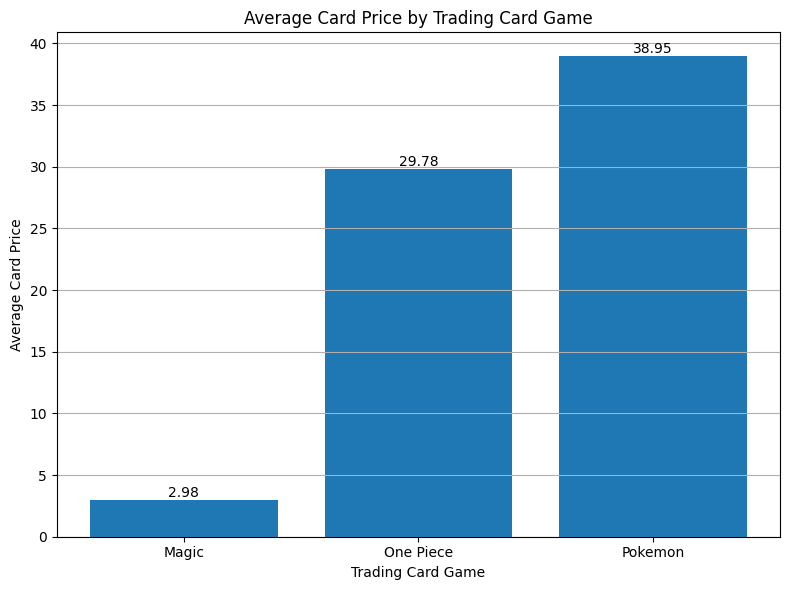

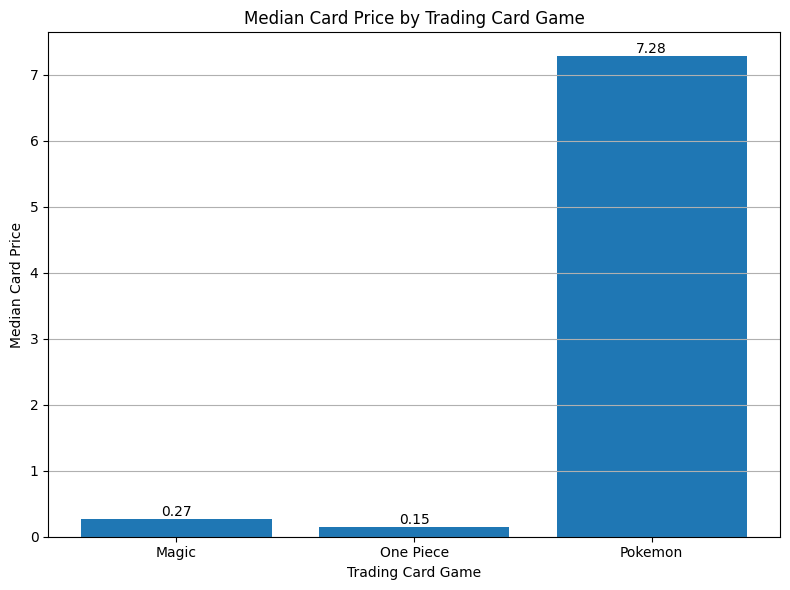

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will answer Brandon Hoang's first question for analysis
# The code will use the price analysis Data Frame
# This program should calculate the number of cards used, what the average,
# median, minimum, and maximum prices of the cards are, print a summary table
# and create a average and median price bar chart(s)
# For this, I will be using both the average and median prices since a few
# very expensive cards could affect the averages of the games too much

# This function will summarize the card prices for each of the trading card
# games
def summarize_trading_card_prices(data_frame):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # This will make sure that all of the required columns exist within the
  # Data Frame
  required_columns = ["tcg", "price"]
  for column_name in required_columns:
    if column_name not in data_frame.columns:
      print("There was an error. Missing Column:", column_name)
      return pd.DataFrame()

  # This groups together the data by trading card game and calculates the
  # summary values
  summary_df = data_frame.groupby("tcg")["price"].agg([
      "count",
      "mean",
      "median",
      "min",
      "max"
  ])

  # This has the program round out the numeric values so that the table is
  # more user friendly
  summary_df = summary_df.round(2)

  # This resets the index so that the tcg column become a normal column again
  summary_df = summary_df.reset_index()

  # This renames the columns so that they are more clear
  summary_df = summary_df.rename(columns={
      "count": "number_of_cards_used",
      "mean": "average_price",
      "median": "median_price",
      "min": "minimum_price",
      "max": "maximum_price"
  })

  # This returns us the finished summary table
  return summary_df

# This function will create a bar chart for the average price of cards by
# their trading card game
def create_average_price_bar_chart(summary_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(summary_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if summary_df.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # This creates the actual bar chart
  plt.figure(figsize=(8, 6))
  bars = plt.bar(summary_df["tcg"], summary_df["average_price"])

  # This adds the chart title
  plt.title("Average Card Price by Trading Card Game")

  # This labels the x and y axis
  plt.xlabel("Trading Card Game")
  plt.ylabel("Average Card Price")

  # This adds on the grid lines so that the chart is easier to read
  plt.grid(True, axis="y")

  # This tightens out the layout so that it fits the screen better
  plt.tight_layout()

  # This will add the exact value above each bar
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() /2, height,
             f"{height:.2f}", ha="center", va="bottom")

  # This shows the chart to the user
  plt.show()

# This function will create a bar chart for the median price of cards by
# their trading card game
def create_median_price_bar_chart(summary_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(summary_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if summary_df.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # This creates the actual bar chart
  plt.figure(figsize=(8, 6))
  bars = plt.bar(summary_df["tcg"], summary_df["median_price"])

  # This adds the chart title
  plt.title("Median Card Price by Trading Card Game")

  # This labels the x and y axis
  plt.xlabel("Trading Card Game")
  plt.ylabel("Median Card Price")

  # This adds on the grid lines so that the chart is easier to read
  plt.grid(True, axis="y")

  # This tightens out the layout so that it fits the screen better
  plt.tight_layout()

  # This will add the exact value above each bar
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() /2, height,
             f"{height:.2f}", ha="center", va="bottom")

  # This shows the chart to the user
  plt.show()

# This function will run the functions together
def answer_to_brandon_first_question(price_data_frame):

  # This prints out the section title
  print("\n" + "=" * 75)
  print("Answer to Brandon Hoang's First Question: Average Card Price Comparison")
  print("=" * 75)

  # This will check if the price analysis Data Frame works
  if not isinstance(price_data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame")
    return pd.DataFrame()

  if price_data_frame.empty:
    print("There was an error: The price analysis Data Frame is empty.")
    return pd.DataFrame()

  # This will print how manu usable rows each game has inside of the Data Frame
  print("Usable Rows Per Card Game:")
  print(price_data_frame["tcg"].value_counts())

  # This will create the summary table
  summary_df = summarize_trading_card_prices(price_data_frame)

  # This will print out the summary table to the user
  print("\nSummary Table:")
  print(summary_df)

  # This will create the average and median price charts
  create_average_price_bar_chart(summary_df)
  create_median_price_bar_chart(summary_df)

  # This returns the summary table so that I can use it later if I need to
  return summary_df

# This will run the whole program while using the price analysis Data Frame
brandon_first_question_summary_of_trading_card_prices = answer_to_brandon_first_question(price_analysis_df)

Are the different card rarities strongly related to the actual card prices across the different trading card games?

In [ ]:
!pip install wordcloud


Answer to Brandon Hoang's Second Question: Rarity and Price Relationship
Summary Table:
          tcg  standard_rarity  number_of_cards_used  median_price
0       Magic     Common / Low                   451          0.13
1       Magic  Premium / Chase                   138          3.32
2       Magic      Rare / High                   467          0.47
3       Magic   Uncommon / Mid                   444          0.21
4   One Piece     Common / Low                   442          0.07
5   One Piece  Premium / Chase                   290          7.22
6   One Piece      Rare / High                   331          0.26
7   One Piece   Uncommon / Mid                   307          0.10
8     Pokemon     Common / Low                   334          0.30
9     Pokemon  Premium / Chase                   684         26.04
10    Pokemon      Rare / High                   202          1.15
11    Pokemon   Uncommon / Mid                   191          0.38


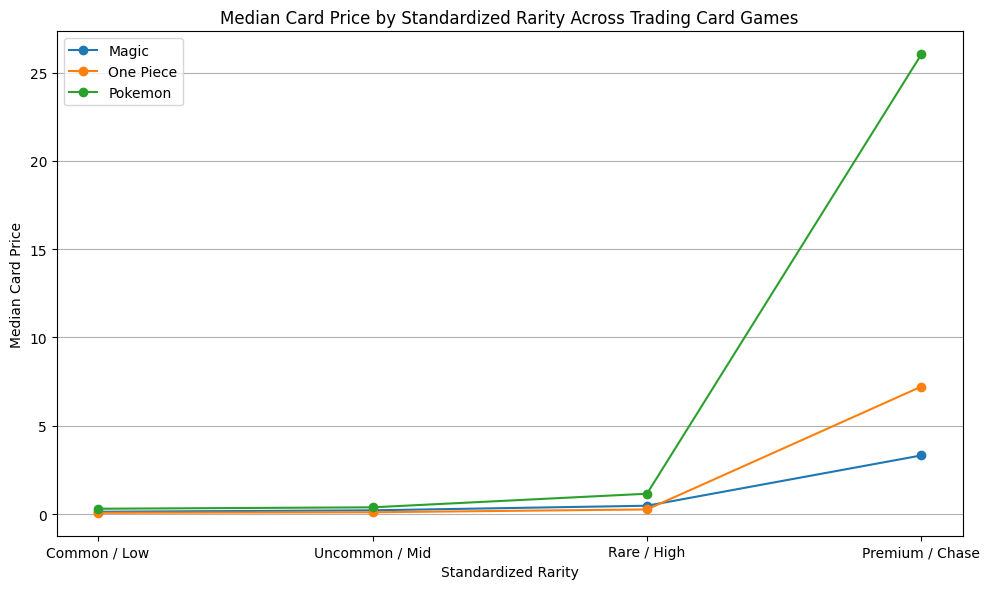

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will answer Brandon Hoang's second question
# This code will use the price analysis Data Frame
# The program will group the cards by their trading card game and use the
# standardized rarities, calculate the median card price for each rarity level,
# print a summary table, and then create one multi-line chart so that I can
# compare the pattern across the games
# Median will be used here since the card price data can have expensive outliers

# This function will create the summary table for median prices by game and
# standardized rarity
def summarize_price_by_standard_rarity(data_frame):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return

  # This will check if the Data Frame is empty or not
  if data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return

  # These are the columns that this question will need
  required_columns = ["tcg", "standard_rarity", "price"]

  # This will make sure that all of the required columns exist
  for column_name in required_columns:
    if column_name not in data_frame.columns:
      print("There was an error. Missing Column:", column_name)
      return pd.DataFrame()

  # This will make a copy of the original Data Frame so that it is not changed
  rarity_price_df = data_frame[required_columns].copy()

  # This will remove all of the rows that do not fit the raritys that we will
  # be using here
  # I will not be including "Other / Unknown" and "Special Type / Leader" since
  # those groups would not compare with the other raritys as cleanly as we
  # would hope for across the games
  rarity_price_df = rarity_price_df[
      rarity_price_df["standard_rarity"].isin([
          "Common / Low",
          "Uncommon / Mid",
          "Rare / High",
          "Premium / Chase"
      ])
  ]

  # This will group up the data by their game and standardized rarity
  # This will then calculate the number of cards and median prices
  summary_df = rarity_price_df.groupby(
      ["tcg", "standard_rarity"]
  )["price"].agg([
      "count",
      "median"
  ]).reset_index()

  # This will rename the columns so that they will be easier for the user to
  # read
  summary_df = summary_df.rename(columns={
      "count": "number_of_cards_used",
      "median": "median_price"
  })

  # This will round off the median prices
  summary_df["median_price"] = summary_df["median_price"].round(2)

  return summary_df

# This function will create the multi-line chart
def create_multi_line_chart_for_card_rarity_prices(summary_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(summary_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return

  # This will check if the Data Frame is empty or not
  if summary_df.empty:
    print("There was an error: The Data Frame is empty.")
    return

  # This will define what the order of rarity groups will be on the x-axis
  rarity_order = [
      "Common / Low",
      "Uncommon / Mid",
      "Rare / High",
      "Premium / Chase"
  ]

  # This will create the figure
  plt.figure(figsize=(10, 6))

  # This will get the unique game names
  game_names = summary_df["tcg"].unique()

  # This will be the overall loop that draws one line for each game
  for game_name in game_names:

    # This will keep only one game's rows at a time for each game
    one_game_rows_df = summary_df[summary_df["tcg"] == game_name].copy()

    # This will make sure that the rarity column will follow the correct rarity
    # order
    one_game_rows_df["standard_rarity"] = pd.Categorical(
        one_game_rows_df["standard_rarity"],
        categories=rarity_order,
        ordered=True
    )

    # This has the program sort out the rows in their rarity order
    one_game_rows_df= one_game_rows_df.sort_values("standard_rarity")

    # This creates the line for the current game
    plt.plot(
        one_game_rows_df["standard_rarity"],
        one_game_rows_df["median_price"],
        marker="o",
        label=game_name
    )

    # This will add the chart title to the graph
    plt.title("Median Card Price by Standardized Rarity Across Trading Card Games")

    # This labels the x and y axis
    plt.xlabel("Standardized Rarity")
    plt.ylabel("Median Card Price")

    # This will add on the grid lines
    plt.grid(True, axis="y")

    # This shows the user the legend
    plt.legend()

    # This will make the layout cleaner
    plt.tight_layout()

  # This shows the chart to the user
  plt.show()

# This function will run everything together
def answer_to_brandon_second_question(price_data_frame):

  # This will print out a section title
  print("\n" + "=" * 75)
  print("Answer to Brandon Hoang's Second Question: Rarity and Price Relationship")
  print("=" * 75)

  # This will make sure that the input is actually a Data Frame
  if not isinstance(price_data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return

  # This will check if the Data Frame is empty or not
  if price_data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return

  # This will create the summary table
  summary_df = summarize_price_by_standard_rarity(price_data_frame)

  # This will create the summary table
  print("Summary Table:")
  print(summary_df)

  # This will create the actual multi-line chart
  create_multi_line_chart_for_card_rarity_prices(summary_df)

  # This will return the summary table
  return summary_df

# This will run the actual code
brandon_second_question_summary = answer_to_brandon_second_question(price_analysis_df)


Support Visual for Brandon Hoang's Second Question: Rarity Word Cloud

Summary Table for Word Cloud:
            rarity  number_of_cards_used  median_price
0        Rare Holo                   625         31.52
1              SEC                    52         17.67
2     Rare Holo EX                    18         15.92
3            Promo                    68         11.04
4                L                   130          9.85
5       Rare Ultra                     5          9.70
6       Rare Shiny                     8          9.49
7     Rare Holo GX                    13          8.88
8               SR                   236          5.30
9   Rare Holo VMAX                     3          3.96
10          mythic                   137          3.29
11     Rare Holo V                     9          1.51
12            Rare                   202          1.15
13            rare                   467          0.47
14        Uncommon                   191          0.38
15               R

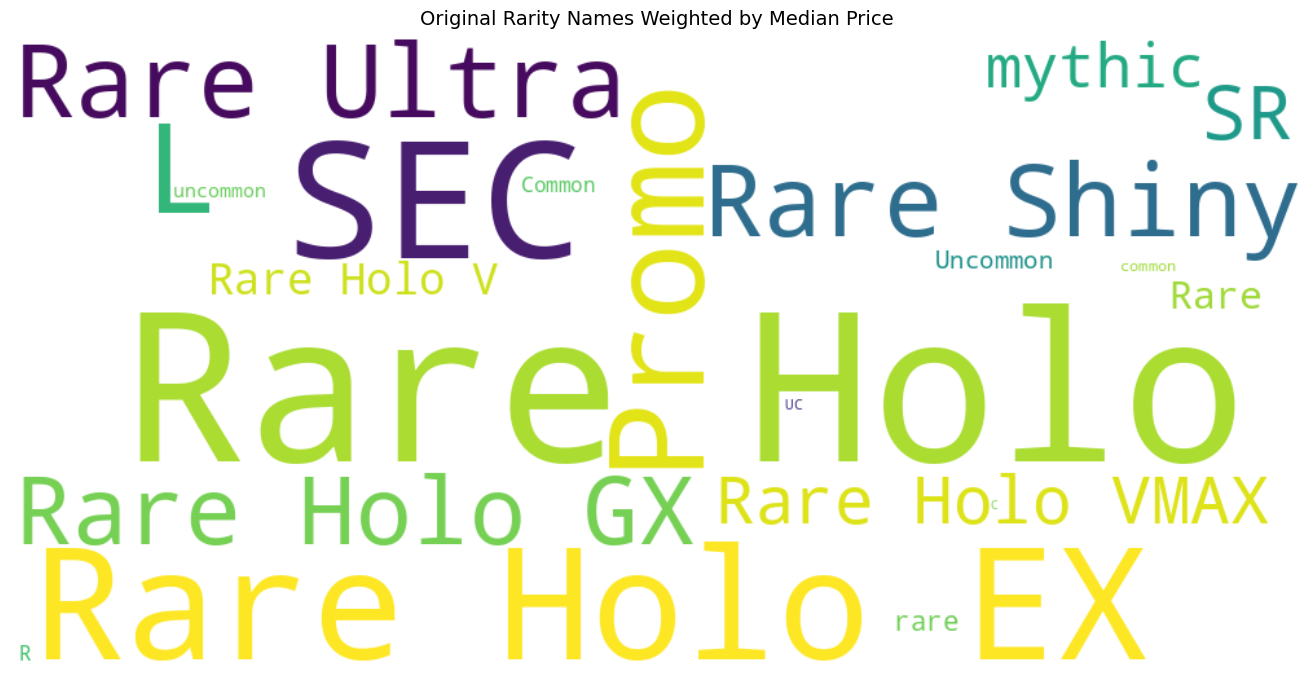

In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will create a word cloud to support the answer to my second question
# This will help show which exact rarity labels tend to have higher prices
# across the three trading card games

# This imports the WordCloud library
from wordcloud import WordCloud

# This function will create a summary table using the original rarity names
# and their median prices
def summarize_original_rarity_wordcloud_data(price_data_frame):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(price_data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if price_data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # These are the columns that this function needs
  required_columns = ["tcg", "rarity", "price"]

  # This will make sure that all of the required columns exist
  for column_name in required_columns:
    if column_name not in price_data_frame.columns:
      print("There was an error. Missing Column:", column_name)
      return pd.DataFrame()

  # This will make a copy of only the columns that we need
  rarity_wordcloud_df = price_data_frame[required_columns].copy()

  # This will remove rows that have missing rarity names
  rarity_wordcloud_df = rarity_wordcloud_df.dropna(subset=["rarity"])

  # This will group the data by original rarity name
  # Then it will calculate how many cards use that rarity and the median price
  summary_df = rarity_wordcloud_df.groupby("rarity")["price"].agg([
      "count",
      "median"
  ]).reset_index()

  # This will rename the columns so that they are easier to understand
  summary_df = summary_df.rename(columns={
      "count": "number_of_cards_used",
      "median": "median_price"
  })

  # This will round off the median prices
  summary_df["median_price"] = summary_df["median_price"].round(2)

  # This will remove rarities that have very few cards
  # This helps make the word cloud a little more fair and readable
  summary_df = summary_df[summary_df["number_of_cards_used"] >= 3].copy()

  # This will sort the Data Frame from highest median price to lowest
  summary_df = summary_df.sort_values("median_price", ascending=False)

  # This will reset the row numbers
  summary_df = summary_df.reset_index(drop=True)

  # This returns the finished summary table
  return summary_df

# This function will create the dictionary that WordCloud needs
def build_wordcloud_frequency_dictionary(summary_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(summary_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return {}

  # This will check if the Data Frame is empty or not
  if summary_df.empty:
    print("There was an error: The Data Frame is empty.")
    return {}

  # This will create an empty dictionary
  word_frequencies = {}

  # This loop will go row by row through the summary table
  for index, row in summary_df.iterrows():

    # This gets the original rarity name
    rarity_name = str(row["rarity"])

    # This gets the median price
    median_price = row["median_price"]

    # WordCloud needs positive numbers
    # If the median price is 0 or less, we will skip it
    if median_price > 0:
      word_frequencies[rarity_name] = median_price

  # This returns the finished dictionary
  return word_frequencies

# This function will create and show the word cloud
def create_original_rarity_wordcloud(word_frequencies):

  # This will make sure that the input is actually a dictionary
  if not isinstance(word_frequencies, dict):
    print("There was an error: Input must be a dictionary.")
    return

  # This will check if the dictionary is empty or not
  if len(word_frequencies) == 0:
    print("There was an error: The word frequency dictionary is empty.")
    return

  # This creates the WordCloud object
  wordcloud = WordCloud(
      width=1000,
      height=500,
      background_color="white",
      colormap="viridis"
  ).generate_from_frequencies(word_frequencies)

  # This creates the figure for the word cloud
  plt.figure(figsize=(14, 7))

  # This displays the word cloud image
  plt.imshow(wordcloud, interpolation="bilinear")

  # This removes the axis lines and numbers
  plt.axis("off")

  # This adds the title
  plt.title("Original Rarity Names Weighted by Median Price", fontsize=14)

  # This makes the layout cleaner
  plt.tight_layout()

  # This shows the final word cloud
  plt.show()

# This function will run everything together
def create_wordcloud_for_brandon_second_question(price_data_frame):

  # This prints a section title
  print("\n" + "=" * 75)
  print("Support Visual for Brandon Hoang's Second Question: Rarity Word Cloud")
  print("=" * 75)

  # This creates the summary table
  summary_df = summarize_original_rarity_wordcloud_data(price_data_frame)

  # This will stop the program if the summary table failed
  if not isinstance(summary_df, pd.DataFrame) or summary_df.empty:
    print("There was an error: Could not build the summary table.")
    return pd.DataFrame()

  # This prints the summary table
  print("\nSummary Table for Word Cloud:")
  print(summary_df)

  # This creates the dictionary for the word cloud
  word_frequencies = build_wordcloud_frequency_dictionary(summary_df)

  # This creates the word cloud
  create_original_rarity_wordcloud(word_frequencies)

  # This returns the summary table in case you need it later
  return summary_df

# This runs the word cloud code
brandon_second_question_wordcloud_summary = create_wordcloud_for_brandon_second_question(price_analysis_df)

Among the top 5 sets in each game, how does the average prices compare between the different sets?

In [ ]:
!pip install plotpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 726.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 429.1/429.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 7.2 MB/s eta 0:00:00


In [ ]:
# Author: Brandon Hoang
# DESIGN NOTES:
# This cell will answer Brandon Hoang's third question
# This code will use the price analysis Data Frame and group the cards by
# trading card game and set name
# The program will calculate the average set price, number of cards used,
# median price, and total set value
# The program will also use Plotly to create a tree map chart

# This import Plotly Express
import plotly.express as px

# This function will summarize the card values for every set
def summarize_set_values(price_data_frame, minimum_cards_required=5):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(price_data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if price_data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # These are the columns that this question needs
  required_columns = ["tcg", "set_name", "price"]

  # This will make sure that all of the required columns exist
  for column_name in required_columns:
    if column_name not in price_data_frame.columns:
      print("There was an error. Missing Column:", column_name)
      return pd.DataFrame()

  # This will make a copy of only the columns that we need
  set_price_df = price_data_frame[required_columns].copy()

  # This will remove rows where the set name is missing
  set_price_df = set_price_df.dropna(subset=["set_name"])

  # This will group the rows by game and set name
  # Then it calculates useful summary values for each set
  summary_df = set_price_df.groupby(["tcg", "set_name"])["price"].agg([
      "count",
      "mean",
      "median",
      "sum",
      "min",
      "max"
  ]).reset_index()

  # This renames the columns so they are easier to understand
  summary_df = summary_df.rename(columns={
      "count": "number_of_cards_used",
      "mean": "average_price",
      "median": "median_price",
      "sum": "total_set_value",
      "min": "minimum_card_price",
      "max": "maximum_card_price"
  })

  # This rounds the numeric columns so the output looks cleaner
  summary_df["average_price"] = summary_df["average_price"].round(2)
  summary_df["median_price"] = summary_df["median_price"].round(2)
  summary_df["total_set_value"] = summary_df["total_set_value"].round(2)
  summary_df["minimum_card_price"] = summary_df["minimum_card_price"].round(2)
  summary_df["maximum_card_price"] = summary_df["maximum_card_price"].round(2)

  # This removes sets that do not have enough cards to make the comparison
  # feel more fair
  summary_df = summary_df[
      summary_df["number_of_cards_used"] >= minimum_cards_required
  ].copy()

  # This resets the row numbers
  summary_df = summary_df.reset_index(drop=True)

  # This returns the finished summary table
  return summary_df

# This function will keep the top 5 sets from each game
def get_top_5_sets_per_game(summary_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(summary_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if summary_df.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # This will sort the sets by game and then by average price from high to low
  sorted_df = summary_df.sort_values(
      by=["tcg", "average_price"],
      ascending=[True, False]
  ).copy()

  # This will keep only the top 5 sets inside each game
  top_5_df = sorted_df.groupby("tcg").head(5).copy()

  # This resets the row numbers
  top_5_df = top_5_df.reset_index(drop=True)

  # This returns the top 5 table
  return top_5_df

# This function will print the top 5 sets for each game
def print_top_5_sets_per_game(top_5_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(top_5_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return

  # This will check if the Data Frame is empty or not
  if top_5_df.empty:
    print("There was an error: The Data Frame is empty.")
    return

  # This gets the different game names one at a time
  game_names = top_5_df["tcg"].unique()

  # This loop prints one game section at a time
  for game_name in game_names:
    print("\nTop 5 sets for", game_name + ":")
    one_game_df = top_5_df[top_5_df["tcg"] == game_name].copy()
    print(one_game_df[[
        "set_name",
        "number_of_cards_used",
        "average_price",
        "median_price",
        "total_set_value"
    ]])

# This function will create one Plotly dot plot for the top 5 sets
# across all three trading card games
def create_plotly_dot_plot_for_top_sets(top_5_df):

  # This will make sure that the input is actually a Data Frame
  if not isinstance(top_5_df, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return

  # This will check if the Data Frame is empty or not
  if top_5_df.empty:
    print("There was an error: The Data Frame is empty.")
    return

  # This will make a copy so that the original Data Frame is not changed
  plot_df = top_5_df.copy()

  # This will create one combined label so that the game and set name
  # both show up clearly on the graph
  plot_df["game_and_set"] = plot_df["tcg"] + " - " + plot_df["set_name"]

  # This will sort the rows from lowest to highest average price so that
  # the graph reads more cleanly from bottom to top
  plot_df = plot_df.sort_values("average_price", ascending=True)

  # This creates one Plotly dot plot
  figure = px.scatter(
      plot_df,
      x="average_price",
      y="game_and_set",
      color="tcg",
      hover_name="set_name",
      hover_data=[
          "number_of_cards_used",
          "median_price",
          "total_set_value",
          "minimum_card_price",
          "maximum_card_price"
      ],
      title="Top 5 Highest-Priced Sets in Each Trading Card Game"
)

  # This makes the dots larger so that they are easier to see
  figure.update_traces(marker=dict(size=12))

  # This updates the axis labels
  figure.update_layout(
      xaxis_title="Average Card Price",
      yaxis_title="Trading Card Game and Set Name",
      height=700
  )

  # This shows the graph
  figure.show()

# This function will run Brandon's third question together
def answer_to_brandon_third_question(price_data_frame):

  # This prints out the section title
  print("\n" + "=" * 75)
  print("Answer to Brandon Hoang's Third Question: Top 5 Highest Set Values in Each TCG")
  print("=" * 75)

  # This will make sure that the input is actually a Data Frame
  if not isinstance(price_data_frame, pd.DataFrame):
    print("There was an error: Input must be a Pandas Data Frame.")
    return pd.DataFrame()

  # This will check if the Data Frame is empty or not
  if price_data_frame.empty:
    print("There was an error: The Data Frame is empty.")
    return pd.DataFrame()

  # This creates the full summary table for all sets
  summary_df = summarize_set_values(price_data_frame, minimum_cards_required=5)

  # This prints part of the full summary table
  print("\nSet Summary Table Preview:")
  print(summary_df.head(15))

  # This keeps only the top 5 sets per game
  top_5_df = get_top_5_sets_per_game(summary_df)

  # This prints the top 5 sets per game
  print_top_5_sets_per_game(top_5_df)

  # This creates the Plotly dot plot
  create_plotly_dot_plot_for_top_sets(top_5_df)

  # This returns the top 5 table in case you want to use it later
  return top_5_df

# This will run Brandon's third question
brandon_third_question_summary = answer_to_brandon_third_question(price_analysis_df)




Answer to Brandon Hoang's Third Question: Top 5 Highest Set Values in Each TCG

Set Summary Table Preview:
      tcg                            set_name  number_of_cards_used  average_price  median_price  total_set_value  minimum_card_price  maximum_card_price
0   Magic  Adventures in the Forgotten Realms                     9           0.61          0.19             5.51                0.09                3.93
1   Magic                       Aether Revolt                    18           0.31          0.12             5.58                0.03                3.37
2   Magic                         Aetherdrift                    12           0.23          0.13             2.74                0.07                0.84
3   Magic                            Amonkhet                     7           9.22          0.14            64.56                0.04               58.35
4   Magic                         Antiquities                     6          22.54          0.84           135.22         

# Aaron's (Aung Kaung Khant) code starts here
# 1: How large is the price multiplier between premium card variants and regular cards across the three card games?

# *Pokemon TCG*

Average price by variant:
variant
1stEditionHolofoil    209.367368
unlimitedHolofoil     105.921053
holofoil               44.479091
reverseHolofoil        39.373292
normal                 17.508947
Name: price, dtype: float64

Overall premium-to-normal price multipliers:
holofoil to normal ratio: 2.54x
reverseHolofoil to normal ratio: 2.25x
1stEditionHolofoil to normal ratio: 11.96x
unlimitedHolofoil to normal ratio: 6.05x


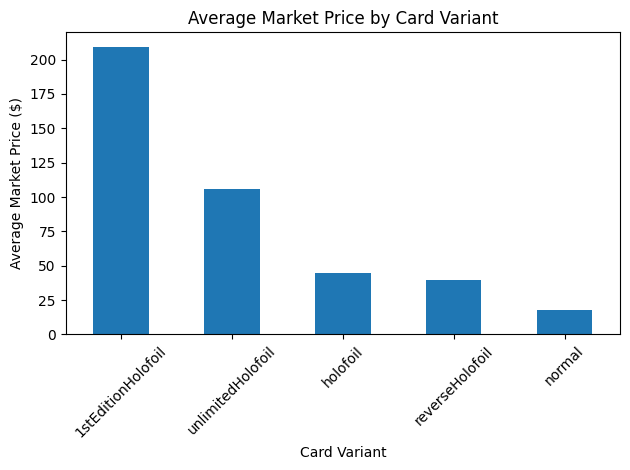

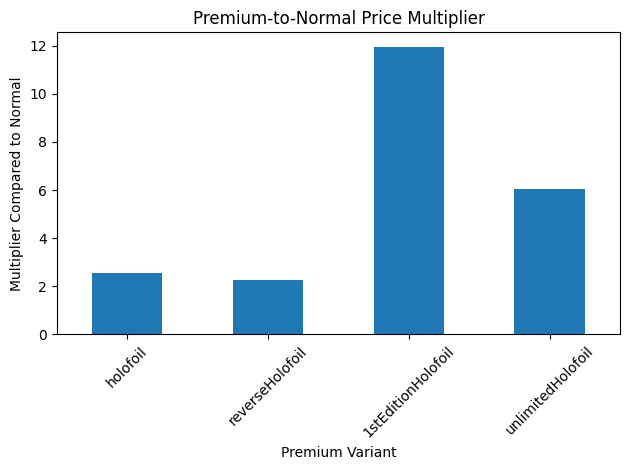

In [ ]:
# Author: Aung Kaung Khant

# 1. How large is the price multiplier between premium card variants and regular cards?

import requests
import pandas as pd
import matplotlib.pyplot as plt

# API endpoint
url = "https://api.pokemontcg.io/v2/cards"

# Get large sample
params = {
    "pageSize": 1000
}

response = requests.get(url, params=params)
data = response.json()

cards = data["data"]

rows = []

# Extract card variant prices
for card in cards:
    card_id = card["id"]
    name = card["name"]

    if "tcgplayer" in card and "prices" in card["tcgplayer"]:
        prices = card["tcgplayer"]["prices"]

        for variant, info in prices.items():
            if "market" in info and info["market"] is not None:
                rows.append({
                    "id": card_id,
                    "name": name,
                    "variant": variant,
                    "price": info["market"]
                })

# Create dataframe
df = pd.DataFrame(rows)

# Average price by variant
avg_prices = df.groupby("variant")["price"].mean().sort_values(ascending=False)

print("Average price by variant:")
print(avg_prices)

# Calculate overall premium-to-normal multipliers
premium_variants = [
    "holofoil",
    "reverseHolofoil",
    "1stEditionHolofoil",
    "unlimitedHolofoil"
]

ratio_results = {}

if "normal" in avg_prices.index:
    normal_avg = avg_prices["normal"]

    print("\nOverall premium-to-normal price multipliers:")

    for variant in premium_variants:
        if variant in avg_prices.index:
            multiplier = avg_prices[variant] / normal_avg
            ratio_results[variant] = multiplier
            print(f"{variant} to normal ratio: {multiplier:.2f}x")
        else:
            print(f"{variant} was not found in the data.")
else:
    print("\nNo normal variant prices found, so multipliers cannot be calculated.")

# Graph average prices by variant
avg_prices.plot(kind="bar")

plt.title("Average Market Price by Card Variant")
plt.xlabel("Card Variant")
plt.ylabel("Average Market Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph premium-to-normal multipliers
if len(ratio_results) > 0:
    ratio_df = pd.Series(ratio_results)

    ratio_df.plot(kind="bar")

    plt.title("Premium-to-Normal Price Multiplier")
    plt.xlabel("Premium Variant")
    plt.ylabel("Multiplier Compared to Normal")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# *One Piece TCG*

200
  card_id                         name           set rarity  variant  price
0    None                       Perona  Romance Dawn     UC  regular   0.94
1    None            Tony Tony.Chopper  Romance Dawn     UC  regular   0.24
2    None                        Otama  Romance Dawn     UC  regular   0.40
3    None  Donquixote Doflamingo (073)  Romance Dawn      R  regular   0.41
4    None                          Izo  Romance Dawn     UC  regular   0.24

Average price by variant:
variant
premium    106.988808
regular     28.677739
Name: price, dtype: float64

Premium-to-regular price multiplier: 3.73x


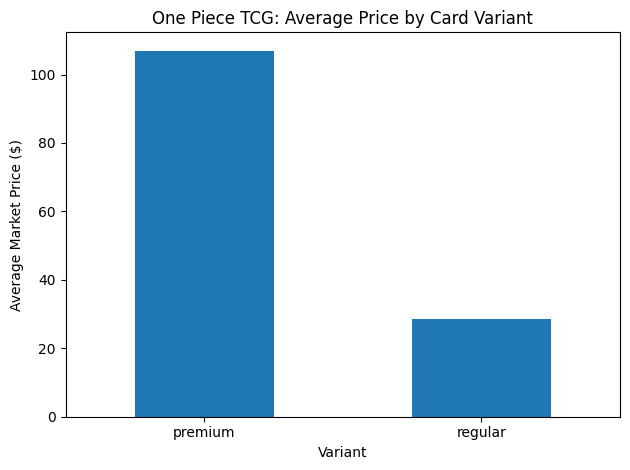

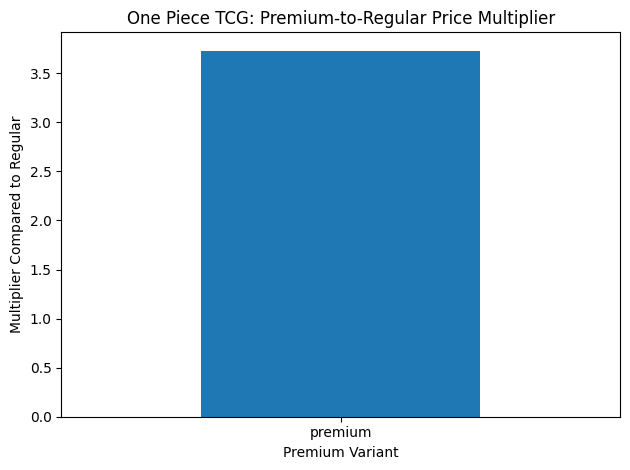

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# One Piece TCG API endpoint
url = "https://optcgapi.com/api/allSetCards/"

response = requests.get(url)
print(response.status_code)

data = response.json()

# API may return either a list or a dictionary
if isinstance(data, dict):
    cards = list(data.values())[0]
else:
    cards = data

rows = []

for card in cards:
    name = card.get("card_name") or card.get("name")
    card_id = card.get("card_id") or card.get("id")
    rarity = card.get("rarity")
    set_name = card.get("set_name")

    market_price = card.get("market_price")

    if market_price is not None:
        # Convert price to float
        price = float(str(market_price).replace("$", "").replace(",", ""))

        # Detect premium variants from name
        if name and ("Parallel" in name or "Alternate Art" in name):
            variant = "premium"
        else:
            variant = "regular"

        rows.append({
            "card_id": card_id,
            "name": name,
            "set": set_name,
            "rarity": rarity,
            "variant": variant,
            "price": price
        })

df = pd.DataFrame(rows)

print(df.head())

# Average price by regular vs premium
avg_prices = df.groupby("variant")["price"].mean()

print("\nAverage price by variant:")
print(avg_prices)

# Multiplier
if "regular" in avg_prices.index and "premium" in avg_prices.index:
    multiplier = avg_prices["premium"] / avg_prices["regular"]
    print(f"\nPremium-to-regular price multiplier: {multiplier:.2f}x")
else:
    print("\nNot enough data to calculate multiplier.")

# Graph
avg_prices.plot(kind="bar")

plt.title("One Piece TCG: Average Price by Card Variant")
plt.xlabel("Variant")
plt.ylabel("Average Market Price ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Graph premium-to-regular multiplier
if "regular" in avg_prices.index and "premium" in avg_prices.index:
    multiplier = avg_prices["premium"] / avg_prices["regular"]

    ratio_df = pd.Series({
        "premium": multiplier
    })

    ratio_df.plot(kind="bar")

    plt.title("One Piece TCG: Premium-to-Regular Price Multiplier")
    plt.xlabel("Premium Variant")
    plt.ylabel("Multiplier Compared to Regular")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Magic

Median price by variant:
variant
foil           0.750
etched foil    0.620
normal         0.315
Name: price, dtype: float64

Premium-to-normal price multipliers:
foil to normal ratio: 2.38x
etched foil to normal ratio: 1.97x


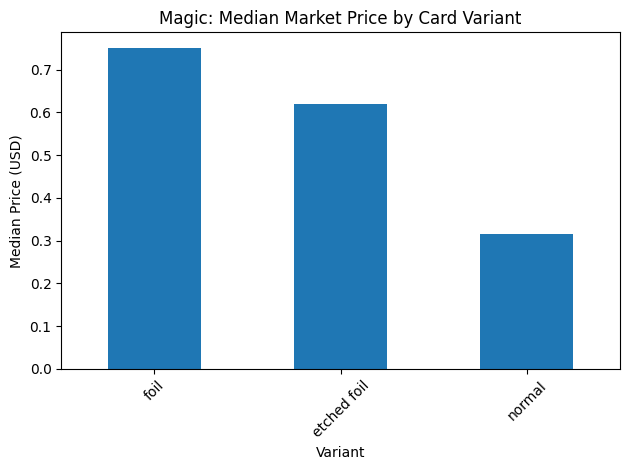

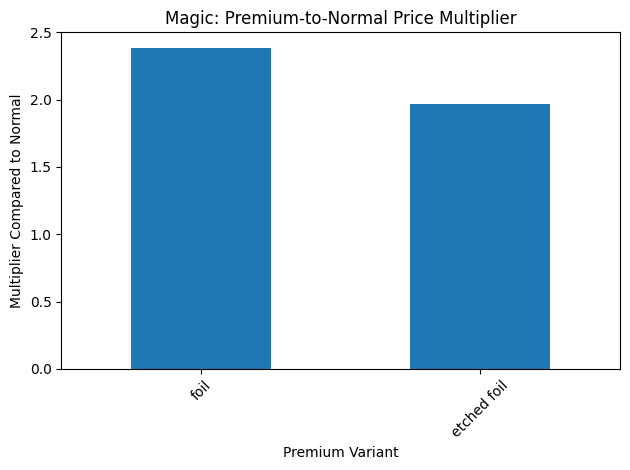

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Scryfall API endpoint
url = "https://api.scryfall.com/cards/search"

# Get Magic cards with USD prices
params = {
    "q": "game:paper usd>=0.01",
    "unique": "prints"
}

response = requests.get(url, params=params)
data = response.json()

cards = data["data"]

rows = []

for card in cards:
    card_id = card["id"]
    name = card["name"]
    set_name = card["set_name"]

    prices = card.get("prices", {})

    usd = prices.get("usd")
    usd_foil = prices.get("usd_foil")
    usd_etched = prices.get("usd_etched")

    if usd is not None:
        rows.append({
            "id": card_id,
            "name": name,
            "set": set_name,
            "variant": "normal",
            "price": float(usd)
        })

    if usd_foil is not None:
        rows.append({
            "id": card_id,
            "name": name,
            "set": set_name,
            "variant": "foil",
            "price": float(usd_foil)
        })

    if usd_etched is not None:
        rows.append({
            "id": card_id,
            "name": name,
            "set": set_name,
            "variant": "etched foil",
            "price": float(usd_etched)
        })

df = pd.DataFrame(rows)

# Remove extreme outliers so very expensive collector cards do not distort the result
df = df[df["price"] <= 1000]

# Use median instead of mean because trading card prices are heavily affected by outliers
median_prices = df.groupby("variant")["price"].median().sort_values(ascending=False)

print("Median price by variant:")
print(median_prices)

normal_median = median_prices["normal"]

print("\nPremium-to-normal price multipliers:")

ratio_results = {}

for variant in ["foil", "etched foil"]:
    if variant in median_prices.index:
        multiplier = median_prices[variant] / normal_median
        ratio_results[variant] = multiplier
        print(f"{variant} to normal ratio: {multiplier:.2f}x")

# Graph median prices
median_prices.plot(kind="bar")

plt.title("Magic: Median Market Price by Card Variant")
plt.xlabel("Variant")
plt.ylabel("Median Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph premium-to-normal multipliers
if len(ratio_results) > 0:
    ratio_df = pd.Series(ratio_results)

    ratio_df.plot(kind="bar")

    plt.title("Magic: Premium-to-Normal Price Multiplier")
    plt.xlabel("Premium Variant")
    plt.ylabel("Multiplier Compared to Normal")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Question 2: Which TCG has the most concentrated high value card games in the market?


High-Value Card Concentration by TCG
         TCG  Total Cards  Top 10% Cards  Total Market Value  Top 10% Market Value  Concentration Percent
0      Magic         1500            150             4471.17               3836.06              85.795441
1  One Piece         1500            150            44672.93              42405.43              94.924219
2    Pokemon         1469            146            57212.44              36223.61              63.314220

Most concentrated high-value market:
One Piece with 94.92 % of value in the top 10% of cards


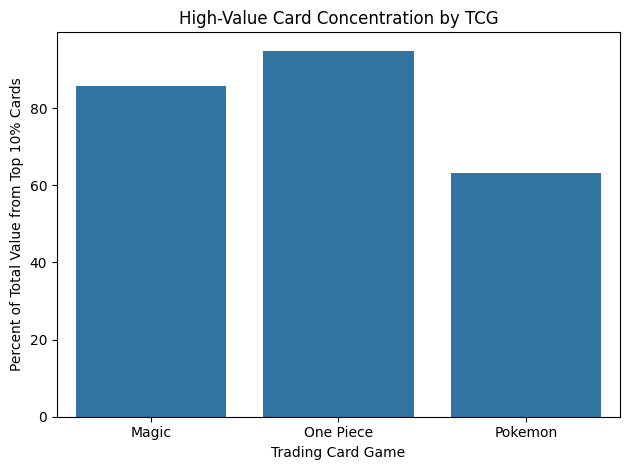

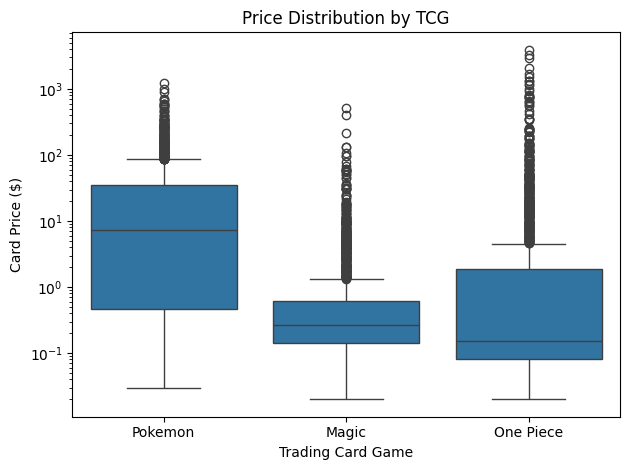

In [ ]:
# Author: Aung Kaung Khant

# Question 2: Which TCG has the most concentrated high-value cards in the market?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_high_value_concentration(combined_df):

    print_out_program_title("High-Value Card Concentration by TCG")

    # Remove missing prices
    valid_prices = combined_df.dropna(subset=["price"]).copy()

    results = []

    for tcg_name, group in valid_prices.groupby("tcg"):

        total_market_value = group["price"].sum()

        # Sort cards from highest price to lowest price
        sorted_group = group.sort_values("price", ascending=False)

        # Top 10% most expensive cards
        top_10_count = max(1, int(len(sorted_group) * 0.10))
        top_10_cards = sorted_group.head(top_10_count)

        top_10_value = top_10_cards["price"].sum()

        # Percent of total value from top 10%
        concentration_percent = (top_10_value / total_market_value) * 100

        results.append({
            "TCG": tcg_name,
            "Total Cards": len(group),
            "Top 10% Cards": top_10_count,
            "Total Market Value": total_market_value,
            "Top 10% Market Value": top_10_value,
            "Concentration Percent": concentration_percent
        })

    results_df = pd.DataFrame(results)

    print(results_df)

    # Find most concentrated TCG
    most_concentrated = results_df.sort_values(
        "Concentration Percent",
        ascending=False
    ).iloc[0]

    print("\nMost concentrated high-value market:")
    print(
        most_concentrated["TCG"],
        "with",
        round(most_concentrated["Concentration Percent"], 2),
        "% of value in the top 10% of cards"
    )

    # Seaborn bar graph
    sns.barplot(
        data=results_df,
        x="TCG",
        y="Concentration Percent"
    )

    plt.title("High-Value Card Concentration by TCG")
    plt.xlabel("Trading Card Game")
    plt.ylabel("Percent of Total Value from Top 10% Cards")
    plt.tight_layout()
    plt.show()

    # Boxplot of card prices by TCG

    sns.boxplot(
        data=valid_prices,
        x="tcg",
        y="price"
    )

    plt.title("Price Distribution by TCG")
    plt.xlabel("Trading Card Game")
    plt.ylabel("Card Price ($)")
    plt.yscale("log")  # Helps visualize extreme prices
    plt.tight_layout()
    plt.show()

    return results_df


concentration_results = analyze_high_value_concentration(combined_df)



# Question 3: Which sets have the widest price range within each TCG?


Set Price Spread Analysis

Top 5 highest price-spread sets per TCG:
           tcg                                     set_name  count  min_price  max_price  mean_price   std_price  price_range
120      Magic                                      Legends      9       0.59     522.25  110.922222  168.581030       521.66
214      Magic                             Ultimate Masters      9       0.06     131.25   15.075556   43.570396       131.19
7        Magic                                  Antiquities      6       0.43     130.42   22.536667   52.855926       129.99
39       Magic  Commander Legends: Battle for Baldur's Gate     25       0.10     108.97   12.310400   25.561045       108.87
197      Magic                                      Tempest      9       0.07      98.11   12.037778   32.373893        98.04
237  One Piece                     Awakening of the New Era    150       0.03    3915.86   73.424667  428.471910      3915.83
238  One Piece                    Emperors in the

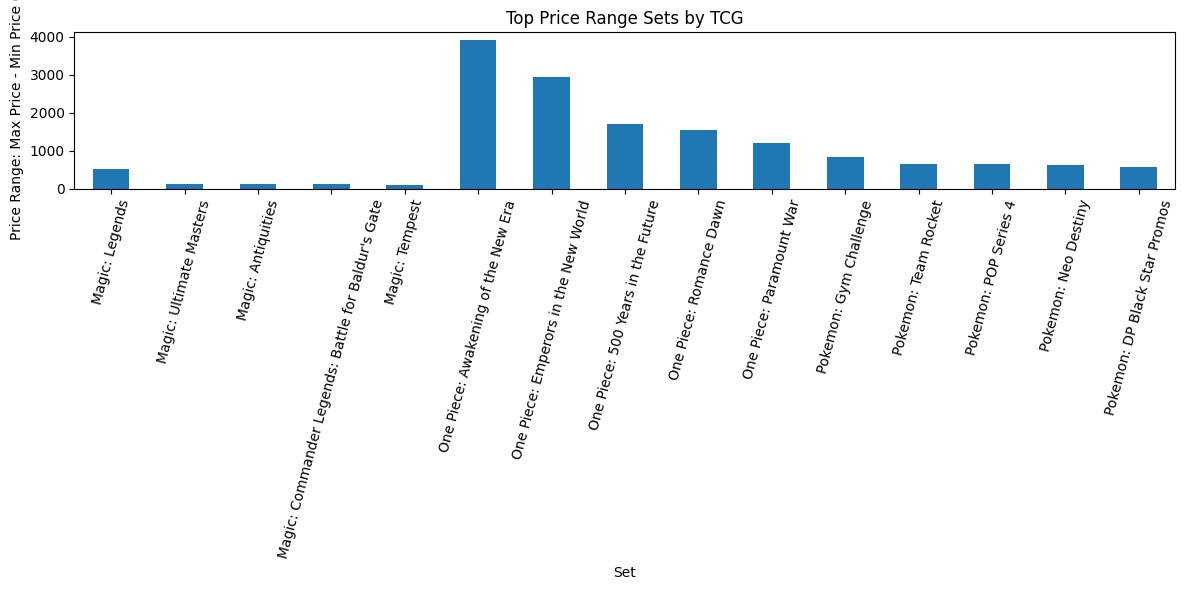

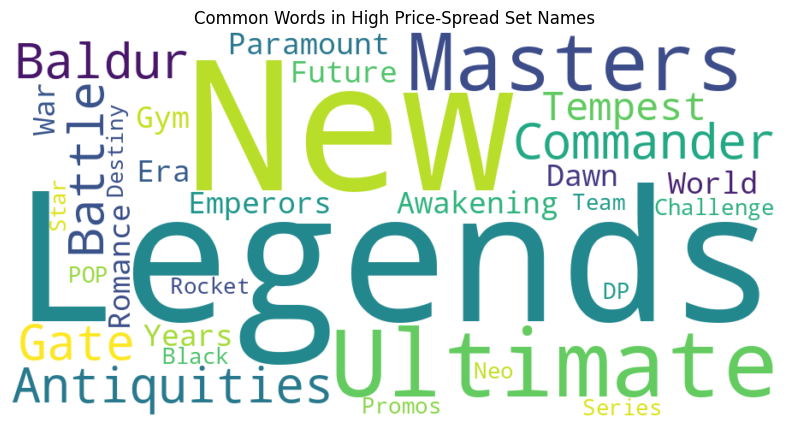

In [ ]:
# Aaron's Question 3:
# Which sets have the widest price range within each TCG?

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

def analyze_set_price_spread(combined_df):

    print_out_program_title("Set Price Spread Analysis")

    valid_prices = combined_df.dropna(subset=["price", "set_name"]).copy()

    set_stats = valid_prices.groupby(["tcg", "set_name"])["price"].agg(
        count="count",
        min_price="min",
        max_price="max",
        mean_price="mean",
        std_price="std"
    ).reset_index()

    # Need enough cards in a set to make spread meaningful
    set_stats = set_stats[set_stats["count"] >= 5]

    set_stats["price_range"] = set_stats["max_price"] - set_stats["min_price"]

    top_spread_sets = (
        set_stats.sort_values(["tcg", "price_range"], ascending=[True, False])
        .groupby("tcg")
        .head(5)
    )

    print("\nTop 5 highest price-spread sets per TCG:")
    print(top_spread_sets)

    # Bar graph
    top_spread_sets["label"] = top_spread_sets["tcg"] + ": " + top_spread_sets["set_name"]

    top_spread_sets.plot(
        kind="bar",
        x="label",
        y="price_range",
        figsize=(12, 6),
        legend=False
    )

    plt.title("Top Price Range Sets by TCG")
    plt.xlabel("Set")
    plt.ylabel("Price Range: Max Price - Min Price ($)")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

    # Word cloud from the high-spread set names
    text = " ".join(top_spread_sets["set_name"].dropna().astype(str))

    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Common Words in High Price-Spread Set Names")
    plt.show()

    return set_stats, top_spread_sets


set_stats, top_spread_sets = analyze_set_price_spread(combined_df)

Natnael Rezene code starts here

In [ ]:
# Natnael code starts here

In [ ]:
# Research Questions:
# 1. How do older cards compare in price and value to newer cards?
# 2. Which sets perform the best over time?
# 3. Which game has the highest prices and biggest price changes?

import pandas as pd
import matplotlib.pyplot as plt
def show_section(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

In [ ]:
# From the new and cleaned dataset
combined_df = price_analysis_df.copy()
print("Data loaded successfully")
print(combined_df.head())
print("\nTotal rows:", len(combined_df))
print("\nCards by game:")
print(combined_df["tcg"].value_counts())

Data loaded successfully
       tcg  card_name     rarity  standard_rarity           set_name  price price_source
0  Pokemon     Aggron  Rare Holo  Premium / Chase      HS—Triumphant   8.10       market
1  Pokemon     Weedle     Common     Common / Low       Primal Clash   0.13       market
2  Pokemon   Ampharos  Rare Holo  Premium / Chase           Platinum  29.34       market
3  Pokemon   Ampharos  Rare Holo  Premium / Chase     Secret Wonders  37.12       market
4  Pokemon  Bulbasaur     Common     Common / Low  Detective Pikachu   0.75       market

Total rows: 4469

Cards by game:
tcg
Magic        1500
One Piece    1500
Pokemon      1469
Name: count, dtype: int64


In [ ]:
# Get data directly from APIs
# Magic data
magic_data = get_magic_api_data()
magic_df = convert_magic_data_into_dataframe(magic_data)

# One Piece data
one_piece_data = get_one_piece_api_data()
rows = []
for card in one_piece_data:
    price = card.get("market_price")
    try:
        price = float(price)
    except:
        price = None
    if price is None:
        continue
    rows.append({
        "tcg": "One Piece",   # FIXED (was "game")
        "card_name": card.get("card_name"),
        "rarity": card.get("rarity"),
        "set_name": card.get("set_name"),
        "price": price
    })
one_piece_df = pd.DataFrame(rows)

# Pokemon data
pokemon_data = get_pokemon_api_data()
rows = []
for card in pokemon_data:
    price = None
    tcgplayer = card.get("tcgplayer", {})
    prices = tcgplayer.get("prices", {}) if isinstance(tcgplayer, dict) else {}
    for variant in prices.values():
        if isinstance(variant, dict) and variant.get("market") is not None:
            price = variant.get("market")
            break
    if price is None:
        continue
    rows.append({
        "tcg": "Pokemon",
        "card_name": card.get("name"),
        "rarity": card.get("rarity"),
        "set_name": card.get("set", {}).get("name"),
        "price": float(price)
    })
pokemon_df = pd.DataFrame(rows)

# Combine all three datasets
combined_df = pd.concat([magic_df, one_piece_df, pokemon_df], ignore_index=True)

# Clean price column
combined_df["price"] = pd.to_numeric(combined_df["price"], errors="coerce")
combined_df = combined_df.dropna(subset=["price"])
print("Data loaded successfully")
print(combined_df.head())
print("\nTotal rows:", len(combined_df))
print("\nCards by game:")
print(combined_df["tcg"].value_counts())

Magic page 1 loaded. Cards so far: 175
Magic page 2 loaded. Cards so far: 350
Magic page 3 loaded. Cards so far: 525
Magic page 4 loaded. Cards so far: 700
Magic page 5 loaded. Cards so far: 875
Magic page 6 loaded. Cards so far: 1050
Magic page 7 loaded. Cards so far: 1225
Magic page 8 loaded. Cards so far: 1400
Magic page 9 loaded. Cards so far: 1575
One Piece cards loaded: 3330
Pokemon page 1 loaded. Cards so far: 250
Pokemon page 2 loaded. Cards so far: 500
Pokemon page 3 loaded. Cards so far: 750
Pokemon page 4 loaded. Cards so far: 1000
Pokemon page 5 loaded. Cards so far: 1250
Pokemon page 6 loaded. Cards so far: 1500
Data loaded successfully
     tcg                card_name    rarity                            set_name  price price_source
0  Magic                    _____  uncommon                            Unhinged   0.42          usd
1  Magic                  +2 Mace    common  Adventures in the Forgotten Realms   0.19          usd
2  Magic  Aang, Airbending Master    mythi


Question 1: Older Cards vs Newer Cards
Average price by age group:
age_group
Newer    18.782499
Older    42.826135
Name: price, dtype: float64

Number of cards per group:
age_group
Newer    3578
Older     890
Name: count, dtype: int64


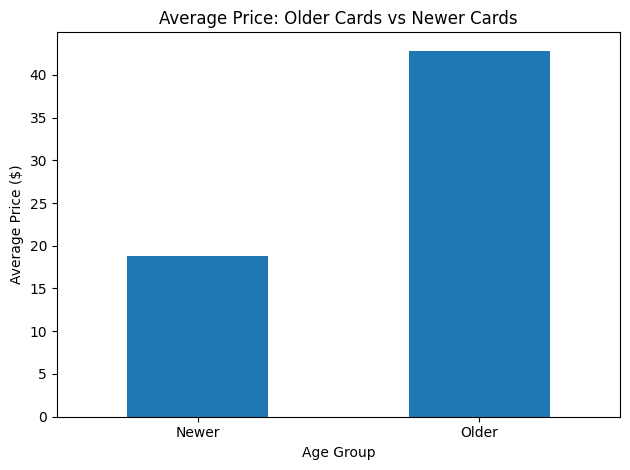


Conclusion: Older cards are more valuable on average in this dataset, probably beacuse they are rarer and collectibles.


In [ ]:
# Question 1: How do older cards compare in price and value to newer cards?
show_section("Question 1: Older Cards vs Newer Cards")
# Better age classification across ALL games
def classify_age(row):
    set_name = str(row["set_name"]).lower()
    tcg = row["tcg"]
    # Older Magic sets
    old_magic_keywords = [
        "alpha", "beta", "arabian nights", "tempest", "odyssey",
        "onslaught", "mirrodin", "unhinged", "innistrad"
    ]
    # Older Pokemon eras / sets
    old_pokemon_keywords = [
        "base", "jungle", "fossil", "team rocket", "gym heroes",
        "gym challenge", "neo", "legendary collection", "ex",
        "diamond & pearl", "platinum", "heartgold", "soulsilver",
        "black & white", "xy", "sun & moon"
    ]
    # Older One Piece sets (earliest releases)
    old_one_piece_keywords = [
        "romance dawn", "paramount war", "pillars of strength"
    ]
    if tcg == "Magic":
        for keyword in old_magic_keywords:
            if keyword in set_name:
                return "Older"
    elif tcg == "Pokemon":
        for keyword in old_pokemon_keywords:
            if keyword in set_name:
                return "Older"
    elif tcg == "One Piece":
        for keyword in old_one_piece_keywords:
            if keyword in set_name:
                return "Older"
    return "Newer"
# Apply classification
combined_df["age_group"] = combined_df.apply(classify_age, axis=1)
# Compute averages
age_comparison = combined_df.groupby("age_group")["price"].mean()
print("Average price by age group:")
print(age_comparison)
# Sample size
print("\nNumber of cards per group:")
print(combined_df["age_group"].value_counts())
# Plot
age_comparison.plot(kind="bar")
plt.title("Average Price: Older Cards vs Newer Cards")
plt.xlabel("Age Group")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Conclusion
if age_comparison["Newer"] > age_comparison["Older"]:
    print("\nConclusion: Newer cards are more valuable on average in this dataset, although classification is based on set name patterns.")
else:
    print("\nConclusion: Older cards are more valuable on average in this dataset, probably beacuse they are rarer and collectibles.")


Question 2: Best Performing Sets
Top 10 sets by average price:
set_name
Skyridge               841.646667
Neo Destiny            279.700667
Expedition Base Set    249.574286
Gym Challenge          223.342222
Arabian Nights         212.545000
Pokémon Rumble         201.761333
Team Rocket            174.288462
Neo Revelation         172.251429
Aquapolis              168.141111
Gym Heroes             165.249333
Name: price, dtype: float64

Number of cards per set (top sets):
set_name
Skyridge                3
Neo Destiny            15
Expedition Base Set     7
Gym Challenge          18
Arabian Nights          2
Pokémon Rumble         15
Team Rocket            13
Neo Revelation         14
Aquapolis               9
Gym Heroes             15
Name: count, dtype: int64


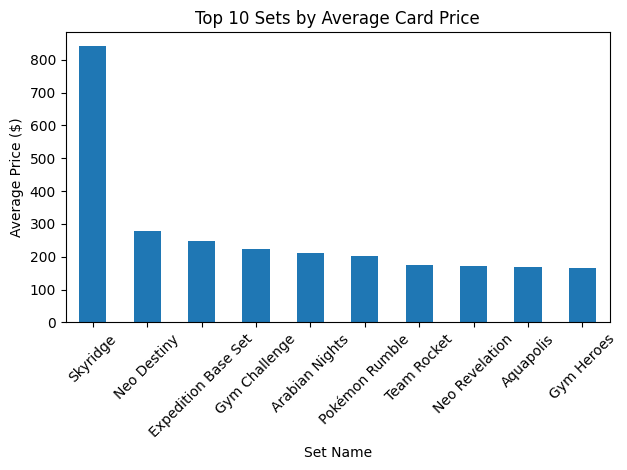


Conclusion: The best performing set is 'Skyridge' with an average price of $841.65.


In [ ]:
# Question 2: Which sets perform the best over time?
show_section("Question 2: Best Performing Sets")
# Average price by set
set_performance = combined_df.groupby("set_name")["price"].mean().sort_values(ascending=False)
print("Top 10 sets by average price:")
print(set_performance.head(10))
set_counts = combined_df["set_name"].value_counts()
print("\nNumber of cards per set (top sets):")
print(set_counts[set_performance.head(10).index])
# Plot top 10 sets
set_performance.head(10).plot(kind="bar")
plt.title("Top 10 Sets by Average Card Price")
plt.xlabel("Set Name")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_set = set_performance.idxmax()
top_price = set_performance.max()

print(f"\nConclusion: The best performing set is '{top_set}' with an average price of ${round(top_price, 2)}.")


Question 3: Game Comparison (Price & Volatility)
Game statistics:
                mean         std
tcg                             
Magic       2.980780   19.992783
One Piece  29.781953  197.920629
Pokemon    38.266308   90.519580


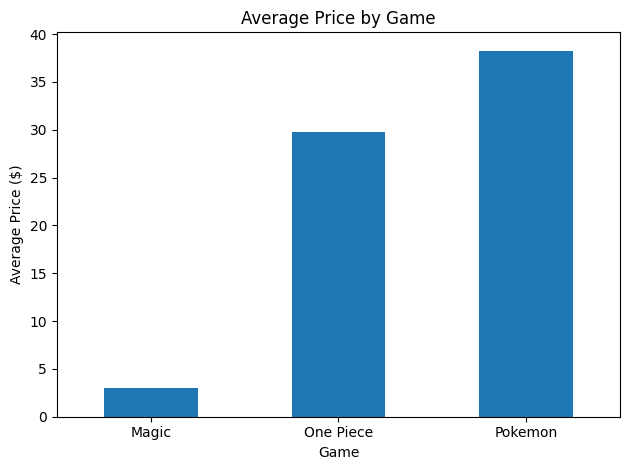

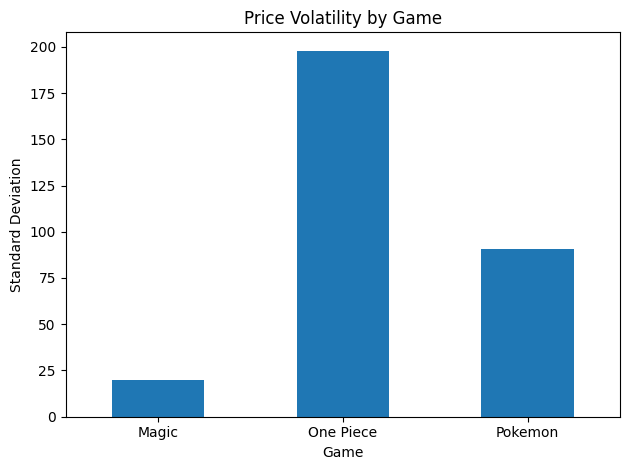


Conclusion: Pokemon has the highest average prices.
Conclusion: One Piece has the biggest price changes (most volatile).


In [ ]:
# Question 3: Which game has the highest prices and biggest price changes?
show_section("Question 3: Game Comparison (Price & Volatility)")
# Average price and volatility (std = price changes)
game_stats = combined_df.groupby("tcg")["price"].agg(["mean", "std"])
print("Game statistics:")
print(game_stats)

# Plot average price
game_stats["mean"].plot(kind="bar")
plt.title("Average Price by Game")
plt.xlabel("Game")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot price volatility
game_stats["std"].plot(kind="bar")
plt.title("Price Volatility by Game")
plt.xlabel("Game")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

highest_avg_game = game_stats["mean"].idxmax()
most_volatile_game = game_stats["std"].idxmax()
print(f"\nConclusion: {highest_avg_game} has the highest average prices.")
print(f"Conclusion: {most_volatile_game} has the biggest price changes (most volatile).")

In [ ]:
#Ranking
show_section("Top 10 Most Valuable Cards")
top_cards = combined_df.sort_values(by="price", ascending=False)
print(top_cards[["tcg", "card_name", "set_name", "age_group", "price"]].head(10))

print("\nConclusion: The highest value cards come from a mix of newer and older sets, often driven by rarity, special editions, and collector demand rather than just age.")


Top 10 Most Valuable Cards
            tcg                                                      card_name                   set_name age_group    price
1948  One Piece                   Monkey.D.Luffy (119) (Alternate Art) (Manga)   Awakening of the New Era     Newer  3915.86
1947  One Piece  Monkey.D.Luffy (012) (Alternate Art) (Gold-Stamped Signature)   Awakening of the New Era     Newer  3282.21
2718  One Piece                                            Gol.D.Roger (Manga)  Emperors in the New World     Newer  2929.01
2715  One Piece                                   Monkey.D.Luffy (119) (Manga)  Emperors in the New World     Newer  2110.82
2090  One Piece                           Boa Hancock (051) (Parallel) (Manga)    500 Years in the Future     Newer  1687.53
1650  One Piece                      Shanks (Parallel) (Manga) (Alternate Art)               Romance Dawn     Older  1532.80
2717  One Piece                                           Shanks (004) (Manga)  Emperors in the N

In [ ]:
#Search Engine
search_term = input("Enter a card name to search: ").lower()
results = combined_df[combined_df["card_name"].str.lower().str.contains(search_term, na=False)]
results = results.sort_values(by="price", ascending=False)
print("\nSearch Results:")
print(results[["tcg", "card_name", "set_name", "price"]].head(10))

Enter a card name to search: pikachu

Search Results:
          tcg          card_name                    set_name   price
3518  Pokemon            Pikachu              Pokémon Rumble  600.00
4418  Pokemon            Pikachu        DP Black Star Promos  119.95
3780  Pokemon            Pikachu                POP Series 6   74.36
3318  Pokemon            Pikachu   Wizards Black Star Promos   43.69
3281  Pokemon            Pikachu  McDonald's Collection 2019   30.06
4312  Pokemon            Pikachu                POP Series 4   27.78
3980  Pokemon            Pikachu      HGSS Black Star Promos   27.57
4400  Pokemon            Pikachu                POP Series 9   17.67
3878  Pokemon            Pikachu        SM Black Star Promos   10.62
3497  Pokemon  Detective Pikachu           Detective Pikachu    9.35



Word Cloud: Common Card Name Words


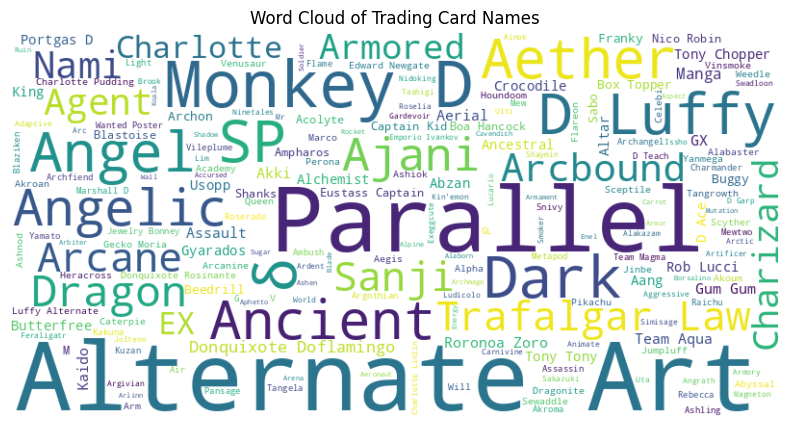

In [ ]:
# Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
show_section("Word Cloud: Common Card Name Words")
text = " ".join(combined_df["card_name"].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Trading Card Names")
plt.show()

In [ ]:
# Final Findings
show_section("Natnael's Findings Summary")
older_avg = combined_df[combined_df["age_group"] == "Older"]["price"].mean()
newer_avg = combined_df[combined_df["age_group"] == "Newer"]["price"].mean()
highest_avg_game = game_stats["mean"].idxmax()
most_volatile_game = game_stats["std"].idxmax()
best_set = set_performance.idxmax()
best_set_price = set_performance.max()
print("Older cards average price: $", round(older_avg, 2))
print("Newer cards average price: $", round(newer_avg, 2))
if older_avg > newer_avg:
    print("Finding 1: Older cards have a higher average price than newer cards.")
else:
    print("Finding 1: Newer cards have a higher average price than older cards.")
print("Finding 2: The best performing set is:", best_set, "with an average price of $", round(best_set_price, 2))
print("Finding 3: The game with the highest average price is:", highest_avg_game)
print("Finding 4: The game with the biggest price changes is:", most_volatile_game)


Natnael's Findings Summary
Older cards average price: $ 42.83
Newer cards average price: $ 18.78
Finding 1: Older cards have a higher average price than newer cards.
Finding 2: The best performing set is: Skyridge with an average price of $ 841.65
Finding 3: The game with the highest average price is: Pokemon
Finding 4: The game with the biggest price changes is: One Piece


#Paul's Analysis of card data

##Question #1
Is there a difference between cost of licensed IPs vs in universe Magic the Gathering Cards

In [ ]:
# Paul code starts here

In [ ]:
from datetime import datetime
def filter_sup_sets(sets_data):
    sup_sets = []
    current_date = datetime.now().date()

    for s in sets_data:
        released = s.get("released_at")

        if not released:
            continue


        released_date = datetime.strptime(released, "%Y-%m-%d").date()

        if released_date > current_date:
            continue

        year = int(released[:4])

        if year < 2023:
            continue

        if s.get("set_type") not in ["masters", "eternal"]:
            continue

        if s.get("digital", False):
            continue

        sup_sets.append({
            "name": s["name"],
            "code": s["code"],
            "released_at": released,
            "search_uri": s["search_uri"]
        })
    return(sup_sets)
#define funtion to filetr only standard sets released since 2024 and have released
def filter_standard_sets(sets_data):
    standard_sets = []
    current_date = datetime.now().date() # Get today's date

    for s in sets_data:
        released = s.get("released_at")

        if not released:
            continue


        released_date = datetime.strptime(released, "%Y-%m-%d").date()

        if released_date > current_date:
            continue

        year = int(released[:4])

        if year < 2023:
            continue

        if s.get("set_type") not in ["expansion", "core"]:
            continue

        if s.get("digital", False):
            continue

        standard_sets.append({
            "name": s["name"],
            "code": s["code"],
            "released_at": released,
            "search_uri": s["search_uri"]
        })
    return(standard_sets)
#define function to fetch all cards from a set based on the search_uri tied to that set
def fetch_all_cards(search_uri):
    cards = []
    url = search_uri

    while url:
        response = requests.get(url)
        response.raise_for_status()

        data = response.json()

        cards.extend(data["data"])

        url = data.get("next_page") if data.get("has_more") else None

        # Add a small delay to avoid hitting API rate limits
        import time
        time.sleep(0.5)

    return cards
#define function to return average price of car in set
def compute_average_price(cards):
    prices = []

    for card in cards:
        usd = card.get("prices", {}).get("usd")

        if usd is not None:
            try:
                prices.append(float(usd))
            except ValueError:
                pass

    if not prices:
        return None

    return sum(prices) / len(prices)
#define function to compute maximum price
def compute_max_price(cards):
    prices = []

    for card in cards:
        usd = card.get("prices", {}).get("usd")

        if usd is not None:
            try:
                prices.append(float(usd))
            except ValueError:
                pass

    if not prices:
        return None

    return max(prices)


#set base url
url = "https://api.scryfall.com"

#query all set data
temp_url = f"{url}/sets"
response = requests.get(temp_url)
response.raise_for_status()
sets = response.json()["data"]

recent_sets = filter_standard_sets(sets)
recent_sup_sets = filter_sup_sets(sets)

set_price = []
sup_price = []

for s in recent_sets:
    cards = fetch_all_cards(s["search_uri"])
    avg_price = compute_average_price(cards)
    max_price = compute_max_price(cards)
    set_price.append({
        "Set": s["name"],
        "Release Date": s["released_at"],
        "Average Price": avg_price,
        "Max Price": max_price,
    })

for s in recent_sup_sets:
    cards = fetch_all_cards(s["search_uri"])
    avg_price = compute_average_price(cards)
    max_price = compute_max_price(cards)
    sup_price.append({
        "Set": s["name"],
        "Release Date": s["released_at"],
        "Average Price": avg_price,
        "Max Price": max_price,
    })


df = pd.DataFrame(set_price)
df2 = pd.DataFrame(sup_price)
print(df)

                                    Set Release Date  Average Price  Max Price
0                 Secrets of Strixhaven   2026-04-24       1.793315      33.39
1          Teenage Mutant Ninja Turtles   2026-03-06       1.454702      35.67
2                       Lorwyn Eclipsed   2026-01-23       1.421065      25.25
3            Avatar: The Last Airbender   2025-11-21       2.299121      64.34
4                   Marvel's Spider-Man   2025-09-26       1.214908      77.15
5                    Edge of Eternities   2025-08-01       2.184211      52.41
6                         Final Fantasy   2025-06-13       3.314083      74.62
7                   Tarkir: Dragonstorm   2025-04-11       1.636278      44.14
8                           Aetherdrift   2025-02-14       0.929875      23.10
9                           Foundations   2024-11-15       1.451005      42.74
10           Duskmourn: House of Horror   2024-09-27       1.674564      26.97
11                          Bloomburrow   2024-08-02

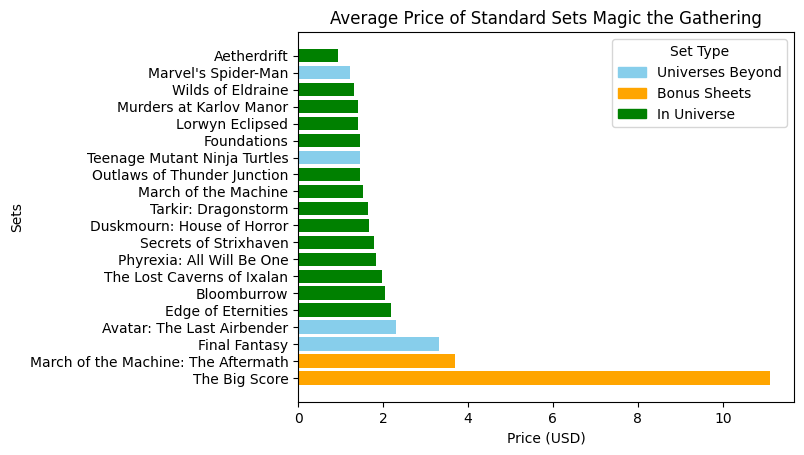

In [ ]:
color_map = {
    "Universes Beyond": {"Set": ["Final Fantasy", "Marvel's Spider-Man", "Avatar: The Last Airbender", "Teenage Mutant Ninja Turtles"], "color": "skyblue"},
    "Bonus Sheets": {"Set": ["March of the Machine: The Aftermath", "The Big Score"], "color": "orange"},
    "In Universe": {"Set": ["Phyrexia: All Will Be One", "March of the Machine", "Wilds of Eldraine", "The Lost Caverns of Ixalan","Murders at Karlov Manor","Outlaws of Thunder Junction","Bloomburrow","Duskmourn: House of Horror","Foundations","Aetherdrift","Tarkir: Dragonstorm","Edge of Eternities","Lorwyn Eclipsed","Secrets of Strixhaven"], "color": "green"}
}

df = df.sort_values(by = "Average Price", ascending = False)

bar_colors = []
for s in df["Set"]:
    assigned_color = "gray"
    for group in color_map.values():
        if s in group["Set"]:
            assigned_color = group["color"]
            break
    bar_colors.append(assigned_color)

plt.barh('Set','Average Price',data = df, color = bar_colors)
plt.ylabel("Sets")
plt.xlabel("Price (USD)")
plt.title("Average Price of Standard Sets Magic the Gathering")
legend_handles = []
for group_name, group_info in color_map.items():
    legend_handles.append(
        plt.Rectangle((0, 0), 1, 1, color=group_info["color"], label=group_name)
    )
plt.legend(handles=legend_handles, title = "Set Type")
plt.show()

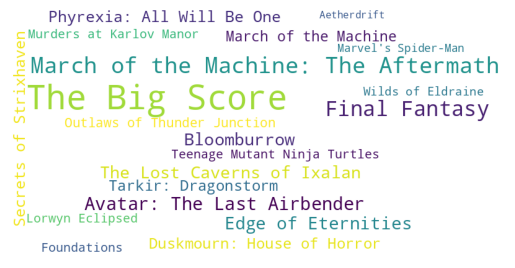

In [ ]:
word_frequencies = dict(zip(df['Set'], df['Average Price']))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_frequencies)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

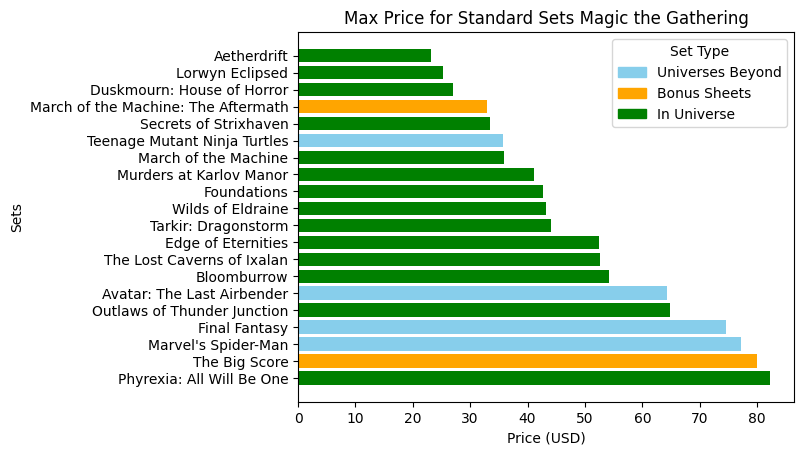

In [ ]:
color_map = {
    "Universes Beyond": {"Set": ["Final Fantasy", "Marvel's Spider-Man", "Avatar: The Last Airbender", "Teenage Mutant Ninja Turtles"], "color": "skyblue"},
    "Bonus Sheets": {"Set": ["March of the Machine: The Aftermath", "The Big Score"], "color": "orange"},
    "In Universe": {"Set": ["Phyrexia: All Will Be One", "March of the Machine", "Wilds of Eldraine", "The Lost Caverns of Ixalan","Murders at Karlov Manor","Outlaws of Thunder Junction","Bloomburrow","Duskmourn: House of Horror","Foundations","Aetherdrift","Tarkir: Dragonstorm","Edge of Eternities","Lorwyn Eclipsed","Secrets of Strixhaven"], "color": "green"}
}

df = df.sort_values(by = "Max Price", ascending = False)

bar_colors = []
for s in df["Set"]:
    assigned_color = "gray"
    for group in color_map.values():
        if s in group["Set"]:
            assigned_color = group["color"]
            break
    bar_colors.append(assigned_color)

plt.barh('Set','Max Price',data = df, color = bar_colors)
plt.ylabel("Sets")
plt.xlabel("Price (USD)")
plt.title("Max Price for Standard Sets Magic the Gathering")
legend_handles = []
for group_name, group_info in color_map.items():
    legend_handles.append(
        plt.Rectangle((0, 0), 1, 1, color=group_info["color"], label=group_name)
    )
plt.legend(handles=legend_handles, title = "Set Type")
plt.show()

##Question #2
is there a diffrence in prices between suplemental (reprint sets) and core sets for Magic the Gathering

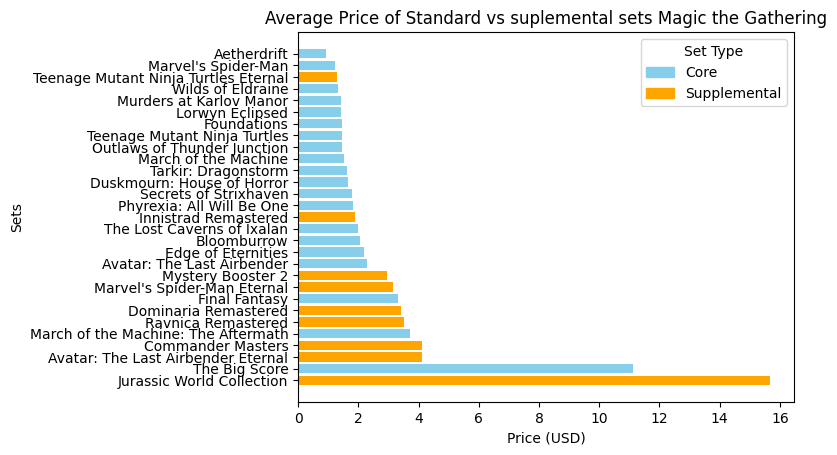

In [ ]:
df['Type'] = 'Core'
df2['Type'] = 'Supplemental'
df3 = pd.concat([df, df2])
df3 = df3.sort_values(by = "Average Price", ascending = False)

color_map = {
    "Core": {"Type": ["Core"], "color": "skyblue"},
    "Supplemental": {"Type": ["Supplemental"], "color": "orange"},
}

bar_colors = []
for s in df3["Type"]:
    assigned_color = "gray"
    for group in color_map.values():
        if s in group["Type"]:
            assigned_color = group["color"]
            break
    bar_colors.append(assigned_color)

plt.barh('Set','Average Price',data = df3, color = bar_colors)
plt.ylabel("Sets")
plt.xlabel("Price (USD)")
plt.title("Average Price of Standard vs suplemental sets Magic the Gathering")
legend_handles = []
for group_name, group_info in color_map.items():
    legend_handles.append(
        plt.Rectangle((0, 0), 1, 1, color=group_info["color"], label=group_name)
    )
plt.legend(handles=legend_handles, title = "Set Type")
plt.show()

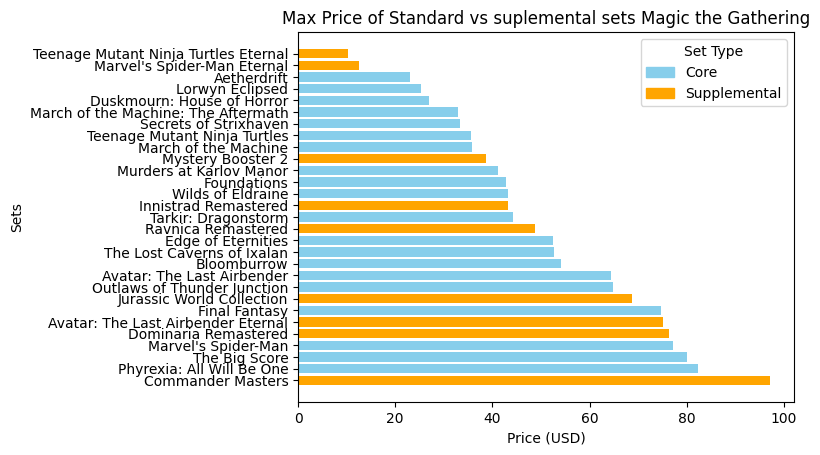

In [ ]:
df3 = df3.sort_values(by = "Max Price", ascending = False)

color_map = {
    "Core": {"Type": ["Core"], "color": "skyblue"},
    "Supplemental": {"Type": ["Supplemental"], "color": "orange"},
}

bar_colors = []
for s in df3["Type"]:
    assigned_color = "gray"
    for group in color_map.values():
        if s in group["Type"]:
            assigned_color = group["color"]
            break
    bar_colors.append(assigned_color)

plt.barh('Set','Max Price',data = df3, color = bar_colors)
plt.ylabel("Sets")
plt.xlabel("Price (USD)")
plt.title("Max Price of Standard vs suplemental sets Magic the Gathering")
legend_handles = []
for group_name, group_info in color_map.items():
    legend_handles.append(
        plt.Rectangle((0, 0), 1, 1, color=group_info["color"], label=group_name)
    )
plt.legend(handles=legend_handles, title = "Set Type")
plt.show()

##Question #3
How does sealed prices vary across card games

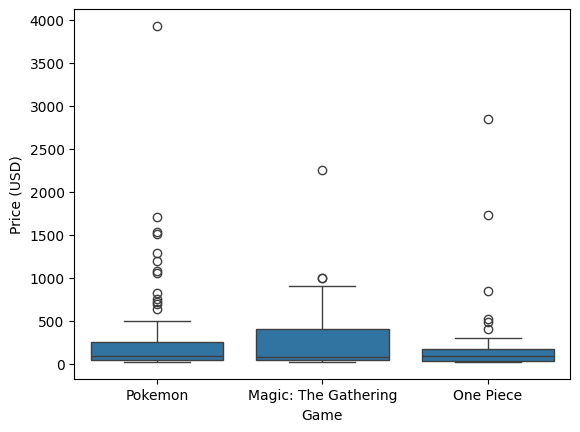

In [ ]:
sealed = pd.read_csv("https://raw.githubusercontent.com/paulfhanscom-lab/Data-for-python-course/main/tcg_market_data.csv")


filtered_sealed = sealed[sealed['game'].isin(['Pokemon', 'One Piece', 'Magic: The Gathering'])]

filtered_sealed = filtered_sealed[filtered_sealed['mid_price'] >= 20]


sns.boxplot(x='game', y='mid_price', data=filtered_sealed)
plt.xlabel('Game')
plt.ylabel('Price (USD)')
plt.show()

**Huda Riaz's TCG Analysis**

In [ ]:
# Huda's Questions:
# 1. Do rare or "chase" cards consistently have higher prices than regular cards across all three games?
# 2. Which trading card game has the most stable market overtime?
# 3. Are newer card sets more valuable than older sets, or vice versa?

**Question 1**

In [ ]:
# Pokemon API Dataset

import requests
import pandas as pd
import matplotlib.pyplot as plt

POKEMON_SET = "swsh12pt5"  # Crown Zenith

url = "https://api.pokemontcg.io/v2/cards"

params = {
    "q": f"set.id:{POKEMON_SET}",
    "pageSize": 250
}

print(f"Pulling Pokémon data for set: {POKEMON_SET}...")

response = requests.get(url, params=params, timeout=60)

print("Status code:", response.status_code)
print("Response preview:")
print(response.text[:500])

response.raise_for_status()
data = response.json()

cards = data.get("data", [])

print("\nCards pulled:", len(cards))

rows = []

def get_market_price(card):
    tcgplayer = card.get("tcgplayer", {})
    prices = tcgplayer.get("prices", {}) if isinstance(tcgplayer, dict) else {}

    variants = [
        "normal",
        "holofoil",
        "reverseHolofoil",
        "1stEditionHolofoil",
        "1stEditionNormal"
    ]

    for variant in variants:
        variant_data = prices.get(variant)

        if isinstance(variant_data, dict):
            market_price = variant_data.get("market")

            if market_price is not None:
                return float(market_price)

    return None

def classify_pokemon_card(rarity):
    rarity = str(rarity).lower()

    chase_words = [
        "rare ultra",
        "rare secret",
        "rare rainbow",
        "rare holo v",
        "rare holo vmax",
        "rare holo vstar",
        "rare holo ex",
        "rare holo gx",
        "illustration rare",
        "special illustration rare",
        "hyper rare"
    ]

    for word in chase_words:
        if word in rarity:
            return "chase"

    return "regular"

for card in cards:
    price = get_market_price(card)

    if price is None:
        continue

    set_info = card.get("set", {})

    rows.append({
        "game": "Pokemon",
        "set_code": POKEMON_SET,
        "set_name": set_info.get("name"),
        "release_date": set_info.get("releaseDate"),
        "card_id": card.get("id"),
        "card_name": card.get("name"),
        "rarity": card.get("rarity"),
        "category": classify_pokemon_card(card.get("rarity")),
        "price": price
    })

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

df.to_csv("pokemon_chase_vs_regular_dataset.csv", index=False)

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean().sort_values(ascending=False))

print("\nAverage price by category:")
print(df.groupby("category")["price"].mean().sort_values(ascending=False))

Pulling Pokémon data for set: swsh12pt5...
Status code: 200
Response preview:
{"data":[{"id":"swsh12pt5-1","name":"Oddish","supertype":"Pokémon","subtypes":["Basic"],"hp":"50","types":["Grass"],"evolvesTo":["Gloom"],"attacks":[{"name":"Leaf Boomerang","cost":["Colorless"],"convertedEnergyCost":1,"damage":"10×","text":"Flip 2 coins. This attack does 10 damage for each heads."}],"weaknesses":[{"type":"Fire","value":"×2"}],"retreatCost":["Colorless"],"convertedRetreatCost":1,"set":{"id":"swsh12pt5","name":"Crown Zenith","series":"Sword & Shield","printedTotal":159,"total":16

Cards pulled: 160

Preview:
      game   set_code      set_name release_date      card_id  card_name    rarity category  price
0  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-1     Oddish    Common  regular   0.13
1  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-2      Gloom  Uncommon  regular   0.12
2  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-3  Bellossom      Rare  regular   0

In [ ]:
# One Piece API Dataset

import requests
import pandas as pd

SET_CODE = "OP01"

url = "https://optcgapi.com/api/allSetCards/"

print("Pulling One Piece card data...")

response = requests.get(url, timeout=60)
response.raise_for_status()

data = response.json()

rows = []

def classify_one_piece(rarity):
    rarity = str(rarity).upper()

    # Higher rarity / chase-type cards
    if rarity in ["SR", "SEC", "SP", "L", "LEADER", "SECRET RARE", "SUPER RARE"]:
        return "chase"
    else:
        return "regular"

for card in data:
    card_id = card.get("card_set_id")

    # Keep only OP01 cards
    if not card_id or not card_id.startswith(SET_CODE):
        continue

    rarity = card.get("rarity")
    price = card.get("market_price")

    rows.append({
        "game": "One Piece",
        "set_code": SET_CODE,
        "set_name": card.get("set_name"),
        "card_id": card_id,
        "card_name": card.get("card_name"),
        "rarity": rarity,
        "category": classify_one_piece(rarity),
        "price": price,
        "card_type": card.get("card_type"),
        "color": card.get("card_color")
    })

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean().sort_values(ascending=False))

print("\nAverage price by category:")
print(df.groupby("category")["price"].mean())

df.to_csv("one_piece_cards_rarity_prices.csv", index=False)

print("\nDataset saved as one_piece_cards_rarity_prices.csv")


Pulling One Piece card data...

Preview:
        game set_code      set_name   card_id                    card_name rarity category  price  card_type  color
0  One Piece     OP01  Romance Dawn  OP01-077                       Perona     UC  regular   0.94  Character   Blue
1  One Piece     OP01  Romance Dawn  OP01-015            Tony Tony.Chopper     UC  regular   0.24  Character    Red
2  One Piece     OP01  Romance Dawn  OP01-006                        Otama     UC  regular   0.40  Character    Red
3  One Piece     OP01  Romance Dawn  OP01-073  Donquixote Doflamingo (073)      R  regular   0.41  Character   Blue
4  One Piece     OP01  Romance Dawn  OP01-033                          Izo     UC  regular   0.24  Character  Green

Rows collected: 199

Average price by rarity:
rarity
SEC    295.553636
L      124.296875
R       82.287750
SR      49.188485
UC       1.264167
C        0.385490
Name: price, dtype: float64

Average price by category:
category
chase      114.384333
regular     24

In [ ]:
# Magic API Dataset

import requests
import pandas as pd
import time

# Magic set code
# "woe" = Wilds of Eldraine
# Other examples:
# "ltr" = Lord of the Rings
# "mom" = March of the Machine
# "dmu" = Dominaria United
MTG_SET = "woe"

url = "https://api.scryfall.com/cards/search"

params = {
    "q": f"set:{MTG_SET} game:paper",
    "unique": "prints",
    "order": "set"
}

rows = []

while url:
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    cards = data.get("data", [])

    for card in cards:
        prices = card.get("prices", {})

        price = prices.get("usd")

        if price is not None:
            price = float(price)

            rarity = card.get("rarity")

            # Classify chase vs regular
            if rarity in ["rare", "mythic"]:
                category = "chase"
            else:
                category = "regular"

            row = {
                "game": "Magic",
                "set_code": MTG_SET,
                "card_id": card.get("id"),
                "card_name": card.get("name"),
                "rarity": rarity,
                "category": category,
                "price": price
            }

            rows.append(row)

    # Scryfall uses pagination
    if data.get("has_more"):
        url = data.get("next_page")
        params = None
        time.sleep(0.6)  # follows Scryfall rate-limit guidance
    else:
        url = None

df = pd.DataFrame(rows)

print(df.head())
print("\nRows collected:", len(df))

df.to_csv("magic_cards_rarity_prices.csv", index=False)

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean())

print("\nAverage price by category:")
print(df.groupby("category")["price"].mean())

print("\nDataset saved as magic_cards_rarity_prices.csv")


    game set_code                               card_id                             card_name  rarity category  price
0  Magic      woe  00174be7-0dc8-43b9-81b6-f25a8c3fb4eb               Archon of the Wild Rose    rare    chase   0.26
1  Magic      woe  e71768e7-4ef7-4fb2-838b-eb3a7f662d38                        Archon's Glory  common  regular   0.11
2  Magic      woe  4b041949-6fb6-40a6-9329-f209be537219                           Armory Mice  common  regular   0.07
3  Magic      woe  5980a930-c7f8-45e1-a18a-87734d9ed09e  Besotted Knight // Betroth the Beast  common  regular   0.22
4  Magic      woe  f7094fc0-1d26-429c-9b49-37718c4a5c80                       Break the Spell  common  regular   0.16

Rows collected: 379

Average price by rarity:
rarity
common      0.227034
mythic      7.697317
rare        0.941417
uncommon    0.394731
Name: price, dtype: float64

Average price by category:
category
chase      2.590179
regular    0.300948
Name: price, dtype: float64

Dataset saved as mag

**Comparison of price difference between rare and regular cards across all three games**

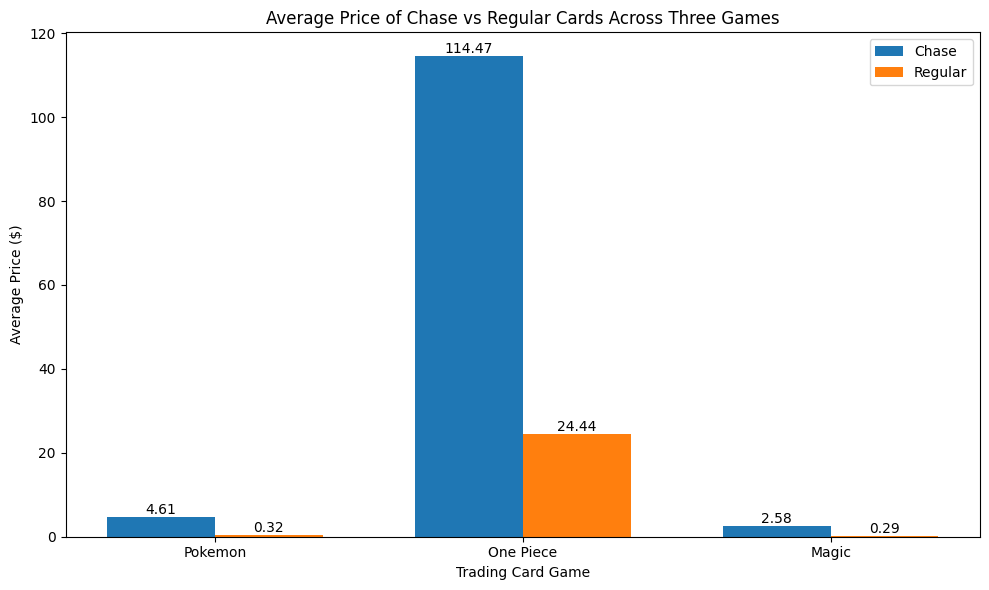

Graph saved as chase_vs_regular_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "game": ["Pokemon", "One Piece", "Magic"],
    "chase": [4.607727, 114.469833, 2.580060],
    "regular": [0.322586, 24.435612, 0.285498]
}

df = pd.DataFrame(data)

# Positions for grouped bars
x = np.arange(len(df["game"]))
width = 0.35

# Create figure
plt.figure(figsize=(10, 6))

# Bars
bars1 = plt.bar(x - width/2, df["chase"], width, label="Chase")
bars2 = plt.bar(x + width/2, df["regular"], width, label="Regular")

# Labels and title
plt.title("Average Price of Chase vs Regular Cards Across Three Games")
plt.xlabel("Trading Card Game")
plt.ylabel("Average Price ($)")
plt.xticks(x, df["game"])
plt.legend()
plt.tight_layout()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

# Save and show
plt.savefig("chase_vs_regular_comparison.png")
plt.show()

print("Graph saved as chase_vs_regular_comparison.png")

**Question 2**

In [ ]:
# Pokemon API Dataset

import requests
import pandas as pd

POKEMON_SET = "swsh12pt5"  # Crown Zenith

url = "https://api.pokemontcg.io/v2/cards"

params = {
    "q": f"set.id:{POKEMON_SET}",
    "pageSize": 250
}

print(f"Pulling Pokémon data for set: {POKEMON_SET}...")

response = requests.get(url, params=params, timeout=60)

print("Status code:", response.status_code)
print("Response preview:")
print(response.text[:500])

response.raise_for_status()
data = response.json()

cards = data.get("data", [])

print("\nCards pulled:", len(cards))

rows = []

def get_market_price(card):
    tcgplayer = card.get("tcgplayer", {})
    prices = tcgplayer.get("prices", {}) if isinstance(tcgplayer, dict) else {}

    variants = [
        "normal",
        "holofoil",
        "reverseHolofoil",
        "1stEditionHolofoil",
        "1stEditionNormal"
    ]

    for variant in variants:
        variant_data = prices.get(variant)

        if isinstance(variant_data, dict):
            market_price = variant_data.get("market")

            if market_price is not None:
                return float(market_price)

    return None

for card in cards:
    price = get_market_price(card)

    if price is None:
        continue

    set_info = card.get("set", {})

    rows.append({
        "game": "Pokemon",
        "set_code": POKEMON_SET,
        "set_name": set_info.get("name"),
        "release_date": set_info.get("releaseDate"),
        "card_id": card.get("id"),
        "card_name": card.get("name"),
        "rarity": card.get("rarity"),
        "price": price
    })

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

df.to_csv("pokemon_market_stability_dataset.csv", index=False)

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean().sort_values(ascending=False))

print("\nPrice stability by rarity:")
print(df.groupby("rarity")["price"].std().sort_values())

print("\nOverall Pokémon market stability score:")
print(df["price"].std())

print("\nDataset saved as pokemon_market_stability_dataset.csv")

Pulling Pokémon data for set: swsh12pt5...
Status code: 200
Response preview:
{"data":[{"id":"swsh12pt5-1","name":"Oddish","supertype":"Pokémon","subtypes":["Basic"],"hp":"50","types":["Grass"],"evolvesTo":["Gloom"],"attacks":[{"name":"Leaf Boomerang","cost":["Colorless"],"convertedEnergyCost":1,"damage":"10×","text":"Flip 2 coins. This attack does 10 damage for each heads."}],"weaknesses":[{"type":"Fire","value":"×2"}],"retreatCost":["Colorless"],"convertedRetreatCost":1,"set":{"id":"swsh12pt5","name":"Crown Zenith","series":"Sword & Shield","printedTotal":159,"total":16

Cards pulled: 160

Preview:
      game   set_code      set_name release_date      card_id  card_name    rarity  price
0  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-1     Oddish    Common   0.13
1  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-2      Gloom  Uncommon   0.12
2  Pokemon  swsh12pt5  Crown Zenith   2023/01/20  swsh12pt5-3  Bellossom      Rare   0.18
3  Pokemon  swsh12pt5  Crown Zen

In [ ]:
# Magic API Dataset

import requests
import pandas as pd
import time

# Magic set:
# woe = Wilds of Eldraine
# ltr = Lord of the Rings
# mom = March of the Machine
# dmu = Dominaria United
MTG_SET = "woe"

url = "https://api.scryfall.com/cards/search"

params = {
    "q": f"set:{MTG_SET} game:paper",
    "unique": "prints",
    "order": "set"
}

rows = []

print(f"Pulling Magic data for set: {MTG_SET}...")

while url:
    response = requests.get(url, params=params, timeout=60)
    print("Status code:", response.status_code)

    response.raise_for_status()
    data = response.json()

    cards = data.get("data", [])

    for card in cards:
        prices = card.get("prices", {})

        price = prices.get("usd")

        # If normal price is missing, use foil price
        if price is None:
            price = prices.get("usd_foil")

        if price is None:
            continue

        try:
            price = float(price)
        except ValueError:
            continue

        rows.append({
            "game": "Magic",
            "set_code": MTG_SET,
            "set_name": card.get("set_name"),
            "card_id": card.get("id"),
            "card_name": card.get("name"),
            "rarity": card.get("rarity"),
            "price": price
        })

    # Handle pagination
    if data.get("has_more"):
        url = data.get("next_page")
        params = None
        time.sleep(0.6)
    else:
        url = None

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean().sort_values(ascending=False))

print("\nPrice stability by rarity:")
print(df.groupby("rarity")["price"].std().sort_values())

print("\nOverall Magic market stability score:")
print(df["price"].std())

df.to_csv("magic_market_dataset.csv", index=False)

print("\nDataset saved as magic_market_dataset.csv")

Pulling Magic data for set: woe...
Status code: 200
Status code: 200
Status code: 200

Preview:
    game set_code           set_name                               card_id                             card_name  rarity  price
0  Magic      woe  Wilds of Eldraine  00174be7-0dc8-43b9-81b6-f25a8c3fb4eb               Archon of the Wild Rose    rare   0.26
1  Magic      woe  Wilds of Eldraine  e71768e7-4ef7-4fb2-838b-eb3a7f662d38                        Archon's Glory  common   0.11
2  Magic      woe  Wilds of Eldraine  4b041949-6fb6-40a6-9329-f209be537219                           Armory Mice  common   0.07
3  Magic      woe  Wilds of Eldraine  5980a930-c7f8-45e1-a18a-87734d9ed09e  Besotted Knight // Betroth the Beast  common   0.22
4  Magic      woe  Wilds of Eldraine  f7094fc0-1d26-429c-9b49-37718c4a5c80                       Break the Spell  common   0.16

Rows collected: 381

Average price by rarity:
rarity
mythic      7.697317
rare        0.933256
uncommon    0.394731
common      0.22703

In [ ]:
# One Piece API Dataset

import requests
import pandas as pd

# One Piece set:
# OP01 = Romance Dawn
# OP02 = Paramount War
# OP03 = Pillars of Strength
# OP04 = Kingdoms of Intrigue
# OP05 = Awakening of the New Era
SET_CODE = "OP01"

url = "https://optcgapi.com/api/allSetCards/"

print(f"Pulling One Piece data for {SET_CODE}...")

response = requests.get(url, timeout=60)
print("Status code:", response.status_code)

response.raise_for_status()
data = response.json()

rows = []

for card in data:
    card_id = card.get("card_set_id")

    # Keep only cards from the selected set
    if not card_id or not card_id.startswith(SET_CODE):
        continue

    price = card.get("market_price")

    try:
        price = float(price)
    except (TypeError, ValueError):
        price = None

    if price is None:
        continue

    rows.append({
        "game": "One Piece",
        "set_code": SET_CODE,
        "set_name": card.get("set_name"),
        "card_id": card_id,
        "card_name": card.get("card_name"),
        "rarity": card.get("rarity"),
        "price": price,
        "inventory_price": card.get("inventory_price"),
        "card_type": card.get("card_type"),
        "color": card.get("card_color")
    })

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

print("\nAverage price by rarity:")
print(df.groupby("rarity")["price"].mean().sort_values(ascending=False))

print("\nPrice stability by rarity:")
print(df.groupby("rarity")["price"].std().sort_values())

print("\nOverall One Piece market stability score:")
print(df["price"].std())

df.to_csv("one_piece_market_dataset.csv", index=False)

print("\nDataset saved as one_piece_market_dataset.csv")

Pulling One Piece data for OP01...
Status code: 200

Preview:
        game set_code      set_name   card_id                    card_name rarity  price  inventory_price  card_type  color
0  One Piece     OP01  Romance Dawn  OP01-077                       Perona     UC   0.94             0.69  Character   Blue
1  One Piece     OP01  Romance Dawn  OP01-015            Tony Tony.Chopper     UC   0.24             0.23  Character    Red
2  One Piece     OP01  Romance Dawn  OP01-006                        Otama     UC   0.40             0.25  Character    Red
3  One Piece     OP01  Romance Dawn  OP01-073  Donquixote Doflamingo (073)      R   0.41             0.20  Character   Blue
4  One Piece     OP01  Romance Dawn  OP01-033                          Izo     UC   0.24             0.23  Character  Green

Rows collected: 199

Average price by rarity:
rarity
SEC    295.553636
L      124.296875
R       82.287750
SR      49.188485
UC       1.264167
C        0.385490
Name: price, dtype: float64

Pri

**Comparing all three market stability scores**

Market Stability Scores:
        game  stability_score
1      Magic             4.05
0    Pokemon             4.69
2  One Piece           216.92


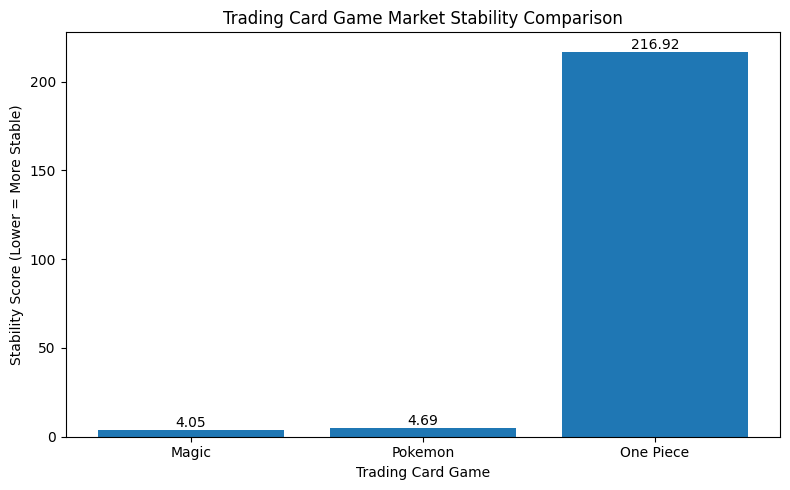


Most stable market: Magic
Least stable market: One Piece


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Final market stability scores
# Lower score = more stable market
data = {
    "game": ["Pokemon", "Magic", "One Piece"],
    "stability_score": [4.69, 4.05, 216.92]
}

df = pd.DataFrame(data)

# Sort from most stable to least stable
df = df.sort_values("stability_score")

print("Market Stability Scores:")
print(df)

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(df["game"], df["stability_score"])

plt.title("Trading Card Game Market Stability Comparison")
plt.xlabel("Trading Card Game")
plt.ylabel("Stability Score (Lower = More Stable)")
plt.tight_layout()

# Add labels above bars
for bar, value in zip(bars, df["stability_score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig("tcg_market_stability_comparison.png")
plt.show()

# Print conclusion
most_stable = df.iloc[0]["game"]
least_stable = df.iloc[-1]["game"]

print(f"\nMost stable market: {most_stable}")
print(f"Least stable market: {least_stable}")

**Question 3**

In [ ]:
# Pokemon API Dataset

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time

url = "https://api.pokemontcg.io/v2/cards"

# Older sets
# base1 = Base Set
# jungle = Jungle
# fossil = Fossil

# Newer sets
# swsh12pt5 = Crown Zenith
# sv1 = Scarlet & Violet
# sv2 = Paldea Evolved

SETS_TO_COMPARE = [
    ("base1", "older"),
    ("jungle", "older"),
    ("fossil", "older"),
    ("swsh12pt5", "newer"),
    ("sv1", "newer"),
    ("sv2", "newer")
]

rows = []

def get_market_price(card):
    """
    Gets the best available TCGPlayer market price.
    Checks multiple print variants because Pokémon cards may have normal,
    holofoil, reverse holofoil, or 1st edition prices.
    """
    tcgplayer = card.get("tcgplayer", {})
    prices = tcgplayer.get("prices", {}) if isinstance(tcgplayer, dict) else {}

    variants = [
        "normal",
        "holofoil",
        "reverseHolofoil",
        "1stEditionHolofoil",
        "1stEditionNormal"
    ]

    for variant in variants:
        variant_data = prices.get(variant)

        if isinstance(variant_data, dict):
            market_price = variant_data.get("market")

            if market_price is not None:
                return float(market_price)

    return None


for set_code, age_group in SETS_TO_COMPARE:
    print(f"\nPulling Pokémon set: {set_code} ({age_group})...")

    params = {
        "q": f"set.id:{set_code}",
        "pageSize": 250
    }

    response = requests.get(url, params=params, timeout=60)

    print("Status code:", response.status_code)
    print("Response preview:", response.text[:300])

    response.raise_for_status()
    data = response.json()

    cards = data.get("data", [])

    print("Cards pulled:", len(cards))

    for card in cards:
        price = get_market_price(card)

        if price is None:
            continue

        set_info = card.get("set", {})

        rows.append({
            "game": "Pokemon",
            "set_code": set_code,
            "set_name": set_info.get("name"),
            "release_date": set_info.get("releaseDate"),
            "age_group": age_group,
            "card_id": card.get("id"),
            "card_name": card.get("name"),
            "rarity": card.get("rarity"),
            "price": price
        })

    time.sleep(0.5)

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

df.to_csv("pokemon_newer_vs_older_sets_dataset.csv", index=False)

print("\nAverage price by age group:")
print(df.groupby("age_group")["price"].mean().sort_values(ascending=False))

print("\nMedian price by age group:")
print(df.groupby("age_group")["price"].median().sort_values(ascending=False))

print("\nAverage price by set:")
print(df.groupby(["age_group", "set_name"])["price"].mean().sort_values(ascending=False))

print("\nMedian price by set:")
print(df.groupby(["age_group", "set_name"])["price"].median().sort_values(ascending=False))


Pulling Pokémon set: base1 (older)...
Status code: 200
Response preview: {"data":[{"id":"base1-1","name":"Alakazam","supertype":"Pokémon","subtypes":["Stage 2"],"level":"42","hp":"80","types":["Psychic"],"evolvesFrom":"Kadabra","abilities":[{"name":"Damage Swap","text":"As often as you like during your turn (before your attack), you may move 1 damage counter from 1 of yo
Cards pulled: 102

Pulling Pokémon set: jungle (older)...
Status code: 200
Response preview: {"data":[],"page":1,"pageSize":250,"count":0,"totalCount":0}
Cards pulled: 0

Pulling Pokémon set: fossil (older)...
Status code: 200
Response preview: {"data":[],"page":1,"pageSize":250,"count":0,"totalCount":0}
Cards pulled: 0

Pulling Pokémon set: swsh12pt5 (newer)...
Status code: 200
Response preview: {"data":[{"id":"swsh12pt5-1","name":"Oddish","supertype":"Pokémon","subtypes":["Basic"],"hp":"50","types":["Grass"],"evolvesTo":["Gloom"],"attacks":[{"name":"Leaf Boomerang","cost":["Colorless"],"convertedEnergyCost":1,"damag

In [ ]:
# Magic API Dataset

import requests
import pandas as pd
import time
from datetime import datetime

# Older sets
OLD_SETS = ["lea", "leb", "arn"]
# lea = Limited Edition Alpha
# leb = Limited Edition Beta
# arn = Arabian Nights

# Newer sets
NEW_SETS = ["woe", "ltr", "mom"]
# woe = Wilds of Eldraine
# ltr = Lord of the Rings
# mom = March of the Machine

ALL_SETS = OLD_SETS + NEW_SETS

rows = []

def get_cards_from_set(set_code, age_group):
    url = "https://api.scryfall.com/cards/search"

    params = {
        "q": f"set:{set_code} game:paper",
        "unique": "prints",
        "order": "set"
    }

    while url:
        response = requests.get(url, params=params, timeout=60)
        print(f"Set {set_code} status code:", response.status_code)

        response.raise_for_status()
        data = response.json()

        cards = data.get("data", [])

        for card in cards:
            prices = card.get("prices", {})

            price = prices.get("usd")

            # If normal price is missing, use foil price
            if price is None:
                price = prices.get("usd_foil")

            if price is None:
                continue

            try:
                price = float(price)
            except ValueError:
                continue

            released_at = card.get("released_at")

            rows.append({
                "game": "Magic",
                "set_code": card.get("set"),
                "set_name": card.get("set_name"),
                "released_at": released_at,
                "age_group": age_group,
                "card_id": card.get("id"),
                "card_name": card.get("name"),
                "rarity": card.get("rarity"),
                "price": price
            })

        if data.get("has_more"):
            url = data.get("next_page")
            params = None
            time.sleep(0.6)
        else:
            url = None

for set_code in OLD_SETS:
    get_cards_from_set(set_code, "older")

for set_code in NEW_SETS:
    get_cards_from_set(set_code, "newer")

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

# Save full dataset
df.to_csv("magic_newer_vs_older_sets_dataset.csv", index=False)

print("\nAverage price by age group:")
print(df.groupby("age_group")["price"].mean().sort_values(ascending=False))

print("\nMedian price by age group:")
print(df.groupby("age_group")["price"].median().sort_values(ascending=False))

print("\nAverage price by set:")
print(df.groupby(["age_group", "set_name"])["price"].mean().sort_values(ascending=False))

print("\nDataset saved as magic_newer_vs_older_sets_dataset.csv")

Set lea status code: 200
Set lea status code: 200
Set leb status code: 200
Set leb status code: 200
Set arn status code: 200
Set woe status code: 200
Set woe status code: 200
Set woe status code: 200
Set ltr status code: 200
Set ltr status code: 200
Set ltr status code: 200
Set ltr status code: 200
Set ltr status code: 200
Set mom status code: 200
Set mom status code: 200
Set mom status code: 200

Preview:
    game set_code               set_name released_at age_group                               card_id      card_name    rarity   price
0  Magic      lea  Limited Edition Alpha  1993-08-05     older  11600105-56c6-4073-a4a6-8469030b39c9  Benalish Hero    common   29.09
1  Magic      lea  Limited Edition Alpha  1993-08-05     older  15967a39-303f-457d-bcde-51837c8d63e1     Black Ward  uncommon   60.00
2  Magic      lea  Limited Edition Alpha  1993-08-05     older  f131fd27-18da-47ca-b59f-135bcac83abd       Blessing      rare  281.99
3  Magic      lea  Limited Edition Alpha  1993-08-05  

In [ ]:
# One Piece API Dataset

import requests
import pandas as pd
import re

url = "https://optcgapi.com/api/allSetCards/"

print("Pulling One Piece card data...")

response = requests.get(url, timeout=60)
print("Status code:", response.status_code)

response.raise_for_status()
data = response.json()

rows = []

def clean_price(value):
    if value in [None, ""]:
        return None

    try:
        return float(value)
    except (TypeError, ValueError):
        return None

def get_set_number(set_id):
    """
    Converts set IDs like OP-01, OP-05, OP-09 into numbers.
    Example: OP-01 -> 1
    """
    if set_id is None:
        return None

    match = re.search(r"OP-?(\d+)", str(set_id))

    if match:
        return int(match.group(1))

    return None

def classify_set_age(set_number):
    """
    Older sets = OP01, OP02, OP03
    Newer sets = OP06 and above

    You can change these ranges if your group wants.
    """
    if set_number in [1, 2, 3]:
        return "older"
    elif set_number is not None and set_number >= 6:
        return "newer"
    else:
        return "middle"

for card in data:
    set_id = card.get("set_id")
    set_number = get_set_number(set_id)
    age_group = classify_set_age(set_number)

    # Skip middle sets so we only compare older vs newer
    if age_group == "middle":
        continue

    price = clean_price(card.get("market_price"))

    if price is None:
        continue

    rows.append({
        "game": "One Piece",
        "set_id": set_id,
        "set_number": set_number,
        "set_name": card.get("set_name"),
        "age_group": age_group,
        "card_id": card.get("card_set_id"),
        "card_name": card.get("card_name"),
        "rarity": card.get("rarity"),
        "price": price,
        "inventory_price": card.get("inventory_price"),
        "card_type": card.get("card_type"),
        "color": card.get("card_color"),
        "date_scraped": card.get("date_scraped")
    })

df = pd.DataFrame(rows)

print("\nPreview:")
print(df.head())

print("\nRows collected:", len(df))

df.to_csv("one_piece_newer_vs_older_sets_dataset.csv", index=False)

print("\nAverage price by age group:")
print(df.groupby("age_group")["price"].mean().sort_values(ascending=False))

print("\nMedian price by age group:")
print(df.groupby("age_group")["price"].median().sort_values(ascending=False))

print("\nAverage price by set:")
print(df.groupby(["age_group", "set_id", "set_name"])["price"].mean().sort_values(ascending=False))

print("\nMedian price by set:")
print(df.groupby(["age_group", "set_id", "set_name"])["price"].median().sort_values(ascending=False))

print("\nDataset saved as one_piece_newer_vs_older_sets_dataset.csv")

Pulling One Piece card data...
Status code: 200

Preview:
        game set_id  set_number      set_name age_group   card_id                    card_name rarity  price  inventory_price  card_type  color date_scraped
0  One Piece  OP-01           1  Romance Dawn     older  OP01-077                       Perona     UC   0.94             0.69  Character   Blue   2026-05-10
1  One Piece  OP-01           1  Romance Dawn     older  OP01-015            Tony Tony.Chopper     UC   0.24             0.23  Character    Red   2026-05-10
2  One Piece  OP-01           1  Romance Dawn     older  OP01-006                        Otama     UC   0.40             0.25  Character    Red   2026-05-10
3  One Piece  OP-01           1  Romance Dawn     older  OP01-073  Donquixote Doflamingo (073)      R   0.41             0.20  Character   Blue   2026-05-10
4  One Piece  OP-01           1  Romance Dawn     older  OP01-033                          Izo     UC   0.24             0.23  Character  Green   2026-05-10


**Comparison of newer vs. older card sets across all three games**

        game   older_avg  newer_avg  older_median  newer_median
0    Pokemon   17.131188   3.772106         2.150          0.15
1  One Piece   20.255433  49.481170         0.195          0.16
2      Magic  149.457235  12.781407        43.910          0.33


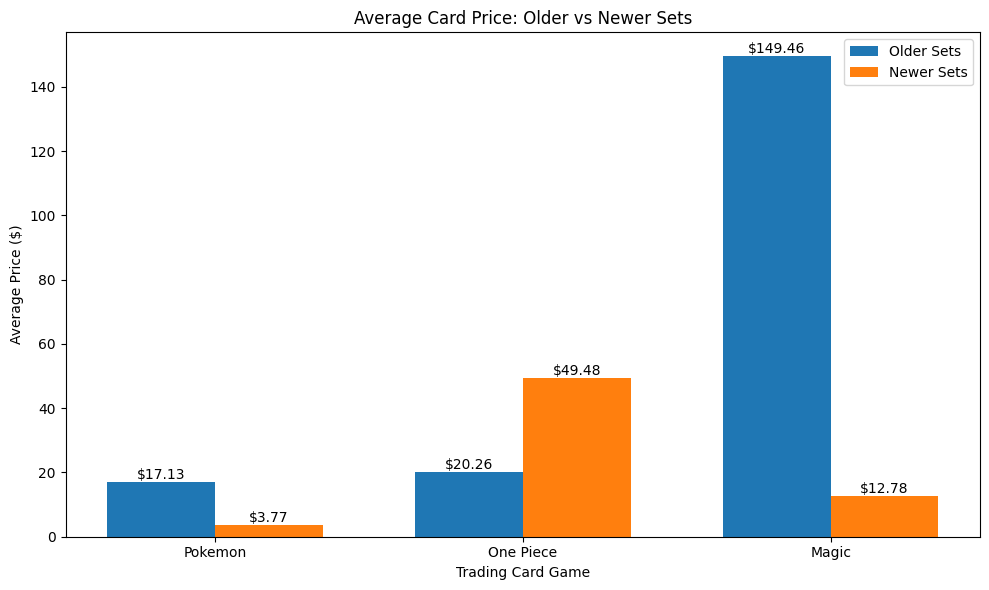

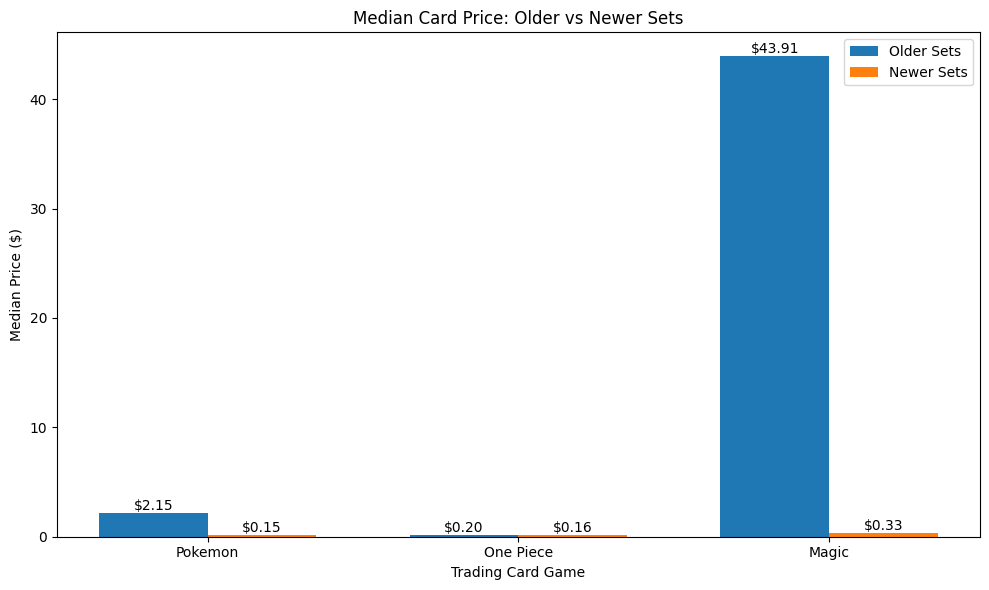

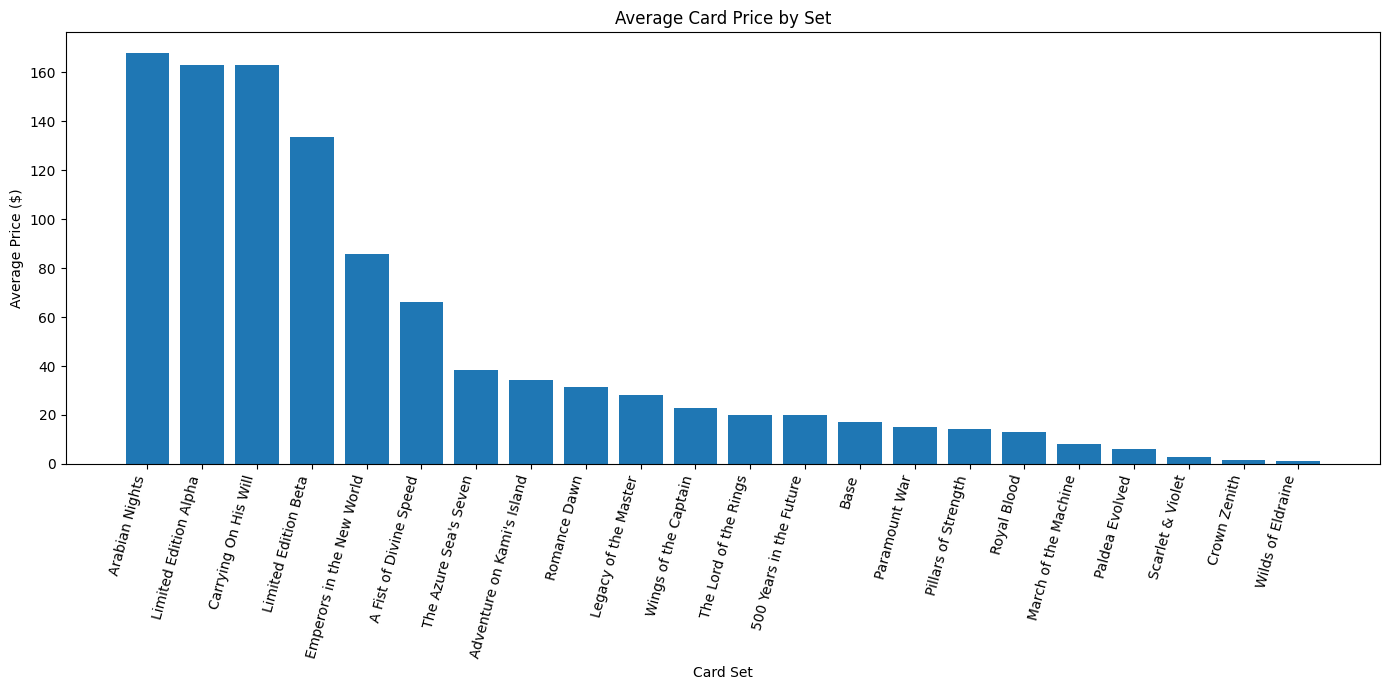


Summary:
Pokemon: Based on averages, older sets have a higher average price. Based on medians, older sets have a higher median price.
One Piece: Based on averages, newer sets have a higher average price. Based on medians, older sets have a higher median price.
Magic: Based on averages, older sets have a higher average price. Based on medians, older sets have a higher median price.

Graphs saved as:
average_price_older_vs_newer.png
median_price_older_vs_newer.png
average_price_by_set.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Data from my results
# --------------------------------------------------

data = {
    "game": ["Pokemon", "One Piece", "Magic"],
    "older_avg": [17.131188, 20.255433, 149.457235],
    "newer_avg": [3.772106, 49.481170, 12.781407],
    "older_median": [2.15, 0.195, 43.91],
    "newer_median": [0.15, 0.160, 0.33]
}

df = pd.DataFrame(data)

print(df)

# --------------------------------------------------
# Graph 1: Average price older vs newer
# --------------------------------------------------

x = np.arange(len(df["game"]))
width = 0.35

plt.figure(figsize=(10, 6))

older_bars = plt.bar(x - width/2, df["older_avg"], width, label="Older Sets")
newer_bars = plt.bar(x + width/2, df["newer_avg"], width, label="Newer Sets")

plt.title("Average Card Price: Older vs Newer Sets")
plt.xlabel("Trading Card Game")
plt.ylabel("Average Price ($)")
plt.xticks(x, df["game"])
plt.legend()

# Add value labels
for bar in older_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.2f}",
        ha="center",
        va="bottom"
    )

for bar in newer_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("average_price_older_vs_newer.png")
plt.show()


# --------------------------------------------------
# Graph 2: Median price older vs newer
# --------------------------------------------------

plt.figure(figsize=(10, 6))

older_median_bars = plt.bar(x - width/2, df["older_median"], width, label="Older Sets")
newer_median_bars = plt.bar(x + width/2, df["newer_median"], width, label="Newer Sets")

plt.title("Median Card Price: Older vs Newer Sets")
plt.xlabel("Trading Card Game")
plt.ylabel("Median Price ($)")
plt.xticks(x, df["game"])
plt.legend()

# Add value labels
for bar in older_median_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.2f}",
        ha="center",
        va="bottom"
    )

for bar in newer_median_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("median_price_older_vs_newer.png")
plt.show()


# --------------------------------------------------
# Graph 3: Set-by-set average prices
# --------------------------------------------------

set_data = {
    "game": [
        "Pokemon", "Pokemon", "Pokemon", "Pokemon",
        "One Piece", "One Piece", "One Piece", "One Piece", "One Piece", "One Piece",
        "One Piece", "One Piece", "One Piece", "One Piece", "One Piece", "One Piece",
        "Magic", "Magic", "Magic", "Magic", "Magic", "Magic"
    ],
    "set_name": [
        "Base",
        "Paldea Evolved",
        "Scarlet & Violet",
        "Crown Zenith",

        "Carrying On His Will",
        "Emperors in the New World",
        "A Fist of Divine Speed",
        "The Azure Sea's Seven",
        "Adventure on Kami's Island",
        "Romance Dawn",
        "Legacy of the Master",
        "Wings of the Captain",
        "500 Years in the Future",
        "Paramount War",
        "Pillars of Strength",
        "Royal Blood",

        "Arabian Nights",
        "Limited Edition Alpha",
        "Limited Edition Beta",
        "The Lord of the Rings",
        "March of the Machine",
        "Wilds of Eldraine"
    ],
    "age_group": [
        "Older", "Newer", "Newer", "Newer",

        "Newer", "Newer", "Newer", "Newer", "Newer", "Older",
        "Newer", "Newer", "Newer", "Older", "Older", "Newer",

        "Older", "Older", "Older", "Newer", "Newer", "Newer"
    ],
    "avg_price": [
        17.131188,
        6.012560,
        2.985160,
        1.501000,

        162.864023,
        85.730818,
        66.311218,
        38.299350,
        34.220249,
        31.350909,
        28.273484,
        22.930331,
        20.047483,
        14.945390,
        14.470000,
        13.208675,

        167.886447,
        162.910476,
        133.362204,
        20.091475,
        8.298542,
        1.298005
    ]
}

set_df = pd.DataFrame(set_data)

# Sort by average price
set_df = set_df.sort_values("avg_price", ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(set_df["set_name"], set_df["avg_price"])

plt.title("Average Card Price by Set")
plt.xlabel("Card Set")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.savefig("average_price_by_set.png")
plt.show()


# --------------------------------------------------
# Printed conclusion helper
# --------------------------------------------------

print("\nSummary:")
for _, row in df.iterrows():
    game = row["game"]

    if row["older_avg"] > row["newer_avg"]:
        avg_result = "older sets have a higher average price"
    else:
        avg_result = "newer sets have a higher average price"

    if row["older_median"] > row["newer_median"]:
        median_result = "older sets have a higher median price"
    else:
        median_result = "newer sets have a higher median price"

    print(f"{game}: Based on averages, {avg_result}. Based on medians, {median_result}.")

print("\nGraphs saved as:")
print("average_price_older_vs_newer.png")
print("median_price_older_vs_newer.png")
print("average_price_by_set.png")

**WordCloud of set names weighted by average price**

Preview:
               set_name   avg_price
0                  Base   17.131188
1        Paldea Evolved    6.012560
2      Scarlet & Violet    2.985160
3          Crown Zenith    1.501000
4  Carrying On His Will  162.864023


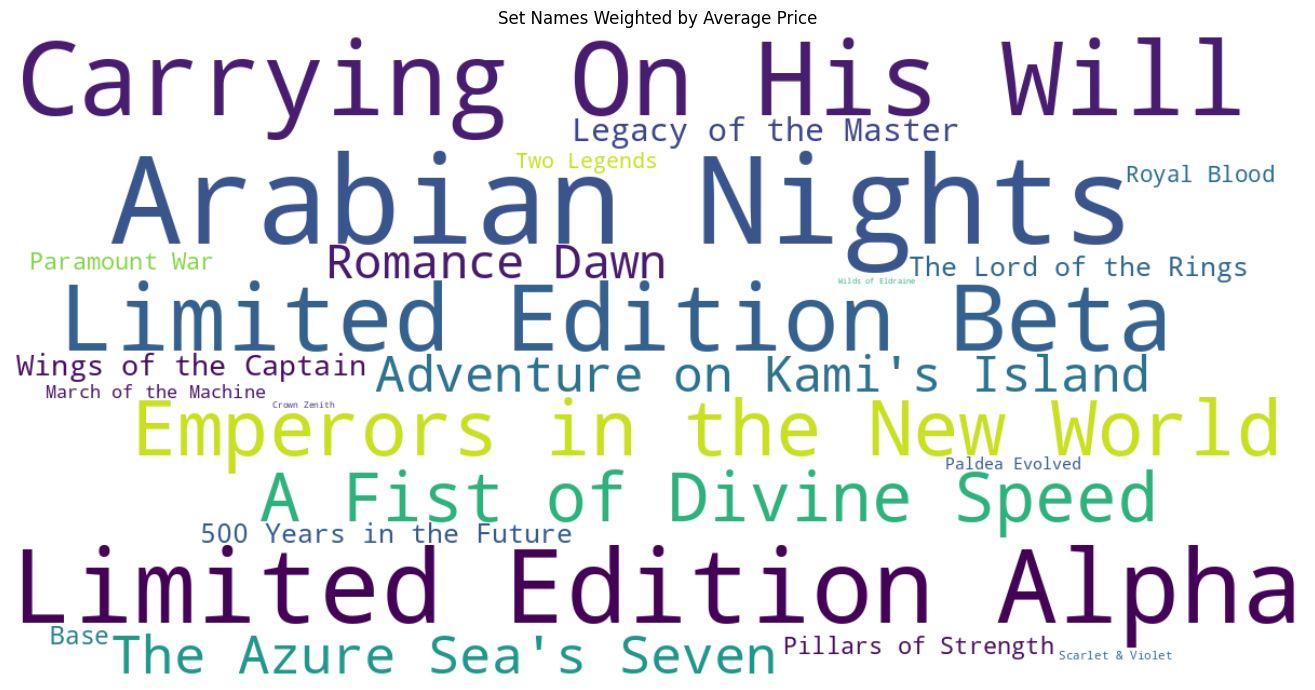

Saved as set_names_weighted_by_average_price_wordcloud.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Sets with higher average prices appear larger
# Sets with lower average prices appear smaller

data = {
    "set_name": [
        # Pokemon
        "Base",
        "Paldea Evolved",
        "Scarlet & Violet",
        "Crown Zenith",

        # One Piece
        "Carrying On His Will",
        "Emperors in the New World",
        "A Fist of Divine Speed",
        "The Azure Sea's Seven",
        "Adventure on Kami's Island",
        "Romance Dawn",
        "Legacy of the Master",
        "Wings of the Captain",
        "500 Years in the Future",
        "Paramount War",
        "Pillars of Strength",
        "Royal Blood",
        "Two Legends",

        # Magic
        "Arabian Nights",
        "Limited Edition Alpha",
        "Limited Edition Beta",
        "The Lord of the Rings",
        "March of the Machine",
        "Wilds of Eldraine"
    ],
    "avg_price": [
        # Pokemon
        17.131188,
        6.012560,
        2.985160,
        1.501000,

        # One Piece
        162.864023,
        85.730818,
        66.311218,
        38.299350,
        34.220249,
        31.350909,
        28.273484,
        22.930331,
        20.047483,
        14.945390,
        14.470000,
        13.208675,
        12.421656,

        # Magic
        167.886447,
        162.910476,
        133.362204,
        20.091475,
        8.298542,
        1.298005
    ]
}

df = pd.DataFrame(data)

print("Preview:")
print(df.head())

# Create dictionary for word cloud
# set name -> average price
word_freq = dict(zip(df["set_name"], df["avg_price"]))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(word_freq)

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Set Names Weighted by Average Price")
plt.tight_layout()
plt.savefig("set_names_weighted_by_average_price_wordcloud.png")
plt.show()

print("Saved as set_names_weighted_by_average_price_wordcloud.png")